# New Day-Ahead Pricing Model
WU Vienna | SBWL Data Science | DSLab 2026S | Marbl Energy

### Summary
Electricity prices in DK1 are not drawn from a single distribution. Wind surplus produces hours with negative prices, scarcity events produce extreme spikes, while the vast majority of days follow a moderate intraday pattern. A single forecasting model trained on this mixture will be pulled in conflicting directions by all three simultaneously. We therefore partition each day into one of four regimes before forecasting: Leaf A (days with at least one negative-price hour), Leaf B (days with at least one hour above the 95th percentile of training prices) and two normal-day clusters (C0 and C1) discovered via Fuzzy C-Means on a PCA-reduced feature space.

A multinomial XGBoost classifier predicts the probability of each regime for the next day using 28 observable features — lag-1 price statistics, rolling momentum, commodity prices (TTF natural gas, CO2 EUA, Brent), ERA5 weather proxies and calendar encodings. Twenty-four expert XGBoost regressors per regime then each predict one hour of the price curve independently. The final 24-hour forecast is a probability-weighted average across all four regime experts.

## Section 0 - Imports and Directory Setup

Runtime environment, imports and output directories required by all subsequent sections.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import holidays
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier, XGBRegressor
import io, contextlib

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", message="A value is trying to be set on a copy")

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Environment ready.")


Environment ready.


In [2]:
config = {
    "zone":                 "DK1",                                       # bidding zone identifier
    "data_path":            "data_new/DK1_masterset_enriched_all.csv",  # enriched hourly input file
    "price_col":            "price_eur_mwh",                             # set below after reading the file
    "spike_pct":            95,                                          # percentile of hourly prices for Leaf B threshold
    "fkm_k_normal":         2,                                           # fixed number of normal-day clusters in Leaf C
    "fkm_m":                2.0,                                         # fuzziness exponent for FCM
    "fkm_error":            0.005,                                       # convergence tolerance for FCM
    "fkm_maxiter":          1000,                                        # maximum FCM iterations
    "clf_params":           {
        "max_depth":        3,     # 8 leaves per tree — cannot memorise 355 samples
        "n_estimators":     300,
        "learning_rate":    0.03,
        "subsample":        0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 8,     # no split on fewer than 8 samples
        "reg_lambda":       2.0,
        "reg_alpha":        0.1,
        },                                          # extra kwargs forwarded to XGBClassifier
    "reg_params":           {
        "max_depth":        3,
        "n_estimators":     300,
        "learning_rate":    0.03,
        "subsample":        0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 5,
        "reg_lambda":       2.0,
        "reg_alpha":        0.1,
        },                                          # extra kwargs forwarded to XGBRegressor                                # maximum FCM iterations
    "pca_variance_target":  0.875,                                       # retain components until this cumulative variance
    "min_cluster_size":     80,  # changed from 40                                        # warn if any cluster falls below this count
    "random_seed":          42,
    "models_dir":           "models/",
    "results_dir":          "results/",
    "fold_definitions": [
        ("2023-01-01", "2023-12-31", "2024-01-01", "2024-12-31"),
        ("2023-01-01", "2024-12-31", "2025-01-01", "2025-12-31"),
        ("2023-01-01", "2025-12-31", "2026-01-01", "2026-04-30"),
    ],
}

# # Confirm the price column name by reading the actual file header.
_cols = pd.read_csv(config["data_path"], nrows=0).columns.tolist()
# price_candidates = [c for c in _cols if "price" in c.lower()]
# if not price_candidates:
#     raise ValueError(f"No price column found. Available columns: {_cols}")
# config["price_col"] = price_candidates[0]
# _pc = config["price_col"]; print(f"price_col confirmed: {_pc}")
print(f"All columns: {_cols}")


All columns: ['timestamp_naive', 'price_eur_mwh', 'temperature_2m', 'wind_speed_10m', 'precipitation_mm', 'solar_radiation_W', 'ttf_gas_eur_mwh', 'co2_eua_eur_tonne', 'brent_usd_bbl', 'load_forecast_Forecasted Load', 'wind_solar_forecast_Solar', 'wind_solar_forecast_Wind Offshore', 'wind_solar_forecast_Wind Onshore', 'generation_forecast']


In [3]:
# df.columns.tolist()

## Section 1 - Data Loading and Validation

### Load and Parse

Before any transformation, the raw data must be validated against four properties: timezone consistency, unbroken hourly frequency, absence of duplicate timestamps and acceptable data quality per column.

In [4]:
df = pd.read_csv(config["data_path"])

# timestamp_naive contains timezone-aware ISO strings (CET/CEST offset); parse directly to UTC.
dt_col = "timestamp_naive"
df[dt_col] = pd.to_datetime(df[dt_col], utc=True)
df = df.set_index(dt_col)
df.index.name = "timestamp"

if df.index.tz is None:
    df.index = df.index.tz_localize("UTC")
    print("Note: index was tz-naive, localized to UTC.")
elif str(df.index.tz) != "UTC":
    df.index = df.index.tz_convert("UTC")

if not df.index.is_monotonic_increasing:
    raise ValueError("Index is not monotonically increasing.")

print(f"Shape:        {df.shape}")
print(f"Index min:    {df.index.min()}")
print(f"Index max:    {df.index.max()}")
print(f"Index dtype:  {df.index.dtype}")
print(f"Monotonic:    {df.index.is_monotonic_increasing}")


Shape:        (28373, 13)
Index min:    2023-01-01 00:00:00+00:00
Index max:    2026-03-28 12:00:00+00:00
Index dtype:  datetime64[ns, UTC]
Monotonic:    True


### Frequency and Gap Check

Electricity price data should have exactly one observation per UTC hour. Missing hours and duplicate hours must be identified and quantified before imputation decisions are made.

In [5]:
expected_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h", tz="UTC")

missing_hours = expected_idx.difference(df.index)
dup_mask  = df.index.duplicated()
dup_hours = df.index[dup_mask]

print(f"Expected hours:   {len(expected_idx):,}")
print(f"Actual hours:     {len(df):,}")
print(f"Missing hours:    {len(missing_hours):,}")
print(f"Duplicate hours:  {len(dup_hours):,}")

if len(dup_hours) > 0:
    print("\nDuplicate timestamps:")
    print(df[df.index.isin(dup_hours)].to_string())
    df = df[~df.index.duplicated(keep="first")]
    print(f"Kept first occurrence of each duplicate. Remaining rows: {len(df):,}")

if len(missing_hours) > 0:
    gaps = []
    gap_start = missing_hours[0]
    prev = missing_hours[0]
    for ts in missing_hours[1:]:
        if (ts - prev).total_seconds() > 3600:
            gaps.append((gap_start, prev, int((prev - gap_start).total_seconds() / 3600) + 1))
            gap_start = ts
        prev = ts
    gaps.append((gap_start, prev, int((prev - gap_start).total_seconds() / 3600) + 1))
    print(f"\n{len(gaps)} gap block(s):")
    for g in gaps:
        flag = "  WARNING: manual inspection required" if g[2] > 3 else ""
        print(f"  {g[0]} -> {g[1]}  ({g[2]}h){flag}")

df = df.reindex(expected_idx)
print(f"\nAfter reindex: {df.shape}")


Expected hours:   28,381
Actual hours:     28,373
Missing hours:    8
Duplicate hours:  0

5 gap block(s):
  2023-10-29 00:00:00+00:00 -> 2023-10-29 01:00:00+00:00  (2h)
  2023-12-30 23:00:00+00:00 -> 2023-12-30 23:00:00+00:00  (1h)
  2024-10-27 00:00:00+00:00 -> 2024-10-27 01:00:00+00:00  (2h)
  2024-12-30 23:00:00+00:00 -> 2024-12-30 23:00:00+00:00  (1h)
  2025-10-26 00:00:00+00:00 -> 2025-10-26 01:00:00+00:00  (2h)

After reindex: (28381, 13)


### Missingness Report

Each column's missingness rate determines the imputation strategy. Short gaps in smooth variables (temperature, wind) are suitable for linear interpolation. Price gaps require more care because electricity prices are not smooth, here forward-fill is inappropriate.

In [6]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(3)
miss_table  = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct}).sort_values("null_pct", ascending=False)
print("Missingness table:")
print(miss_table.to_string())

def _print_null_blocks(series, name):
    is_null = series.isnull()
    if not is_null.any():
        return
    null_idx = series.index[is_null]
    block_start = null_idx[0]
    prev = null_idx[0]
    for ts in null_idx[1:]:
        if (ts - prev).total_seconds() > 3600:
            length = int((prev - block_start).total_seconds() / 3600) + 1
            print(f"  {name}: {block_start} -> {prev}  ({length}h)")
            block_start = ts
        prev = ts
    length = int((prev - block_start).total_seconds() / 3600) + 1
    print(f"  {name}: {block_start} -> {prev}  ({length}h)")

price_col = config["price_col"]

_entso_candidates = [
    "load_forecast_Forecasted Load",
    "wind_solar_forecast_Solar",
    "wind_solar_forecast_Wind Offshore",
    "wind_solar_forecast_Wind Onshore",
    "generation_forecast",
]
entso_cols     = [c for c in _entso_candidates if c in df.columns]
weather_cols   = [c for c in df.columns if any(k in c.lower() for k in ["wind", "temp", "solar", "precip", "radiation"])
                  and c not in entso_cols]
commodity_cols = [c for c in df.columns if c not in weather_cols and c != price_col and c not in entso_cols]

# Price: linear interpolation for gaps <= 3h.
price_null_before = df[price_col].isnull().sum()
df[price_col] = df[price_col].interpolate(method="time", limit=3)
print(f"\nPrice: interpolated {price_null_before - df[price_col].isnull().sum()} gaps (<= 3h).")

# Weather: linear interpolation for gaps <= 6h.
for col in weather_cols:
    before = df[col].isnull().sum()
    df[col] = df[col].interpolate(method="time", limit=6)
    after  = df[col].isnull().sum()
    if before > 0:
        print(f"Weather {col}: interpolated {before - after}, {after} remaining.")

# Commodity: forward-fill up to 72h (weekend exchange closures).
for col in commodity_cols:
    before = df[col].isnull().sum()
    df[col] = df[col].ffill(limit=72)
    after  = df[col].isnull().sum()
    if before > 0:
        print(f"Commodity {col}: forward-filled {before - after}, {after} remaining.")
        if after > 0:
            print(f"  WARNING: {after} remaining nulls in {col} -- gap exceeds 3 days.")

# ---------------------------------------------------------------------------
# ENTSO-E forecast columns imputation
# Five-step cascade: nighttime zero-fill (solar) → short interpolation →
# lag-24h → lag-168h → generation_forecast load-ratio proxy.
# ---------------------------------------------------------------------------
_solar_col      = "wind_solar_forecast_Solar"
_load_col       = "load_forecast_Forecasted Load"
_gen_col        = "generation_forecast"

for col in entso_cols:
    # Step 1 — Solar nighttime zero-fill (solar column only).
    if col == _solar_col:
        night_mask = df[col].isnull() & ((df.index.hour < 5) | (df.index.hour >= 22))
        n_night = night_mask.sum()
        if n_night > 0:
            df.loc[night_mask, col] = 0.0
            print(f"ENTSO-E {col}: nighttime zero-fill filled {n_night}, {df[col].isnull().sum()} remaining.")

    # Step 2 — Short gap interpolation (≤ 3h).
    before = df[col].isnull().sum()
    if before > 0:
        df[col] = df[col].interpolate(method="time", limit=3)
        after = df[col].isnull().sum()
        if before > after:
            print(f"ENTSO-E {col}: interpolation filled {before - after}, {after} remaining.")

    # Step 3 — Medium gap fill via lag-24h.
    before = df[col].isnull().sum()
    if before > 0:
        lag24 = df[col].shift(24)
        mask  = df[col].isnull() & lag24.notna()
        df.loc[mask, col] = lag24[mask]
        after = df[col].isnull().sum()
        if before > after:
            print(f"ENTSO-E {col}: lag-24h filled {before - after}, {after} remaining.")

    # Step 4 — Long gap fill via lag-168h.
    before = df[col].isnull().sum()
    if before > 0:
        lag168 = df[col].shift(168)
        mask   = df[col].isnull() & lag168.notna()
        df.loc[mask, col] = lag168[mask]
        after = df[col].isnull().sum()
        if before > after:
            print(f"ENTSO-E {col}: lag-168h filled {before - after}, {after} remaining.")
        if after > 0:
            print(f"  WARNING: {after} remaining nulls in {col} after all lag fills.")
            _print_null_blocks(df[col], col)


print("\nMissingness after imputation:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "  None.")

# Drop days where price is still NaN after imputation.
price_null_days = df[df[price_col].isnull()].index.normalize().unique()
if len(price_null_days) > 0:
    print(f"\nDropped {len(price_null_days)} days due to unresolvable price gaps: {price_null_days.date.tolist()}")
    df = df[~df.index.normalize().isin(price_null_days)]
else:
    print("No days dropped for unresolvable price gaps.")

Missingness table:
                                   null_count  null_pct
wind_solar_forecast_Wind Onshore          174     0.613
wind_solar_forecast_Wind Offshore         131     0.462
generation_forecast                       107     0.377
wind_solar_forecast_Solar                  59     0.208
load_forecast_Forecasted Load              11     0.039
solar_radiation_W                           8     0.028
precipitation_mm                            8     0.028
wind_speed_10m                              8     0.028
temperature_2m                              8     0.028
price_eur_mwh                               8     0.028
brent_usd_bbl                               8     0.028
ttf_gas_eur_mwh                             8     0.028
co2_eua_eur_tonne                           8     0.028

Price: interpolated 8 gaps (<= 3h).
Weather temperature_2m: interpolated 8, 0 remaining.
Weather wind_speed_10m: interpolated 8, 0 remaining.
Weather precipitation_mm: interpolated 8, 0 remaining.

### Outlier Inspection

Extreme electricity prices are not errors. Scarcity events and renewable surplus events produce genuinely extreme values that carry important regime signal. The goal here is to identify and inspect.

p0.1 threshold:  -37.76 EUR/MWh
p99.9 threshold: 403.88 EUR/MWh
High outliers (>403.9): 29
Low outliers  (<-37.8):  29

High outliers (first 20):
                           price_eur_mwh
2023-09-11 17:00:00+00:00         524.27
2023-09-11 18:00:00+00:00         448.13
2024-11-05 16:00:00+00:00         472.99
2024-11-05 17:00:00+00:00         431.02
2024-11-06 16:00:00+00:00         550.00
2024-12-11 15:00:00+00:00         437.87
2024-12-11 16:00:00+00:00         434.86
2024-12-12 06:00:00+00:00         599.99
2024-12-12 07:00:00+00:00         655.60
2024-12-12 08:00:00+00:00         646.76
2024-12-12 09:00:00+00:00         543.83
2024-12-12 10:00:00+00:00         465.36
2024-12-12 11:00:00+00:00         404.99
2024-12-12 12:00:00+00:00         415.30
2024-12-12 13:00:00+00:00         490.34
2024-12-12 14:00:00+00:00         668.49
2024-12-12 15:00:00+00:00         818.98
2024-12-12 16:00:00+00:00         936.28
2024-12-12 17:00:00+00:00         674.18
2024-12-12 18:00:00+00:00         

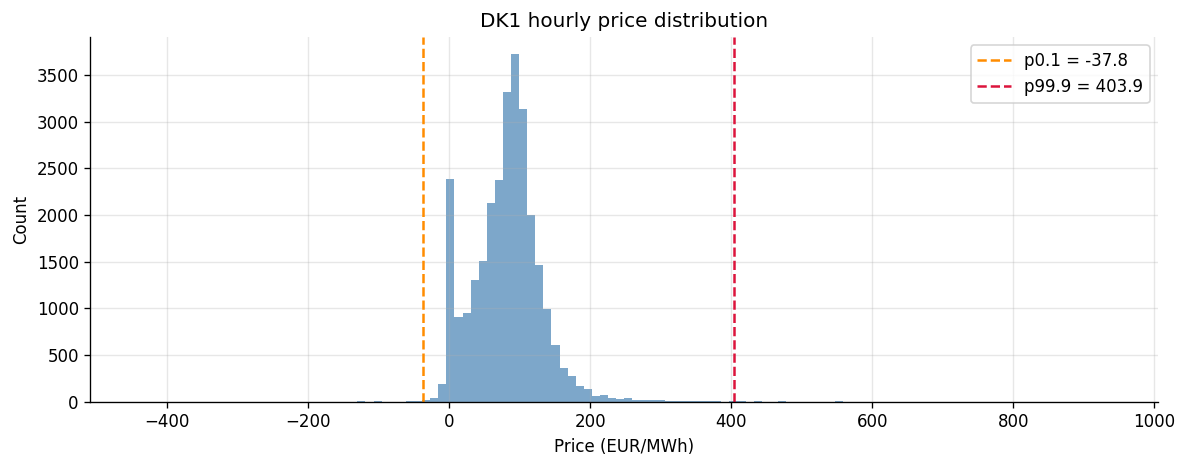

Saved: results/price_distribution.png

Negative price hours: 1,104  (3.89% of total)


In [7]:
p001 = np.percentile(df[price_col].dropna(), 0.1)
p999 = np.percentile(df[price_col].dropna(), 99.9)

high_outliers = df[df[price_col] > p999]
low_outliers  = df[df[price_col] < p001]

print(f"p0.1 threshold:  {p001:.2f} EUR/MWh")
print(f"p99.9 threshold: {p999:.2f} EUR/MWh")
print(f"High outliers (>{p999:.1f}): {len(high_outliers):,}")
print(f"Low outliers  (<{p001:.1f}):  {len(low_outliers):,}")

if len(high_outliers) > 0:
    print("\nHigh outliers (first 20):")
    print(high_outliers[[price_col]].head(20).to_string())
if len(low_outliers) > 0:
    print("\nLow outliers (first 20):")
    print(low_outliers[[price_col]].head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[price_col].dropna(), bins=120, color="steelblue", alpha=0.7)
ax.axvline(p001, color="darkorange", linewidth=1.5, linestyle="--", label=f"p0.1 = {p001:.1f}")
ax.axvline(p999, color="crimson",    linewidth=1.5, linestyle="--", label=f"p99.9 = {p999:.1f}")
ax.set_xlabel("Price (EUR/MWh)")
ax.set_ylabel("Count")
ax.set_title("DK1 hourly price distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/price_distribution.png", dpi=120)
plt.show()
print("Saved: results/price_distribution.png")

neg_hours   = (df[price_col] < 0).sum()
total_hours = df[price_col].notna().sum()
print(f"\nNegative price hours: {neg_hours:,}  ({100 * neg_hours / total_hours:.2f}% of total)")

### Validated Data Summary

The data is now clean and ready for feature engineering.

In [8]:
df_hourly = df.copy()

total_hours = len(df_hourly)
total_days  = df_hourly.index.normalize().nunique()
price_s     = df_hourly[price_col]
neg_pct     = 100 * (price_s < 0).sum() / price_s.notna().sum()

print("=== Validated Data Summary ===")
print(f"Total hours:           {total_hours:,}")
print(f"Total days:            {total_days:,}")
print(f"Date range:            {df_hourly.index.min().date()} -> {df_hourly.index.max().date()}")
print(f"Price mean:            {price_s.mean():.2f} EUR/MWh")
print(f"Price std:             {price_s.std():.2f} EUR/MWh")
print(f"Price min:             {price_s.min():.2f} EUR/MWh")
print(f"Price max:             {price_s.max():.2f} EUR/MWh")
print(f"Negative price hours:  {neg_pct:.2f}%")
print()
for col in df_hourly.columns:
    if col != price_col:
        s = df_hourly[col].dropna()
        print(f"  {col:<28s} mean={s.mean():.3f}  std={s.std():.3f}")

print(f"\ndf_hourly ready: {df_hourly.shape}")


=== Validated Data Summary ===
Total hours:           28,381
Total days:            1,183
Date range:            2023-01-01 -> 2026-03-28
Price mean:            81.06 EUR/MWh
Price std:             49.88 EUR/MWh
Price min:             -440.10 EUR/MWh
Price max:             936.28 EUR/MWh
Negative price hours:  3.89%

  temperature_2m               mean=9.334  std=5.923
  wind_speed_10m               mean=5.609  std=2.636
  precipitation_mm             mean=0.109  std=0.233
  solar_radiation_W            mean=120.035  std=190.282
  ttf_gas_eur_mwh              mean=37.659  std=8.930
  co2_eua_eur_tonne            mean=72.663  std=9.356
  brent_usd_bbl                mean=76.732  std=8.885
  load_forecast_Forecasted Load mean=2611.408  std=474.948
  wind_solar_forecast_Solar    mean=276.247  std=451.571
  wind_solar_forecast_Wind Offshore mean=568.574  std=296.421
  wind_solar_forecast_Wind Onshore mean=915.249  std=697.409
  generation_forecast          mean=2468.265  std=1062.162

df_h

In [9]:
df_hourly.columns.tolist()

['price_eur_mwh',
 'temperature_2m',
 'wind_speed_10m',
 'precipitation_mm',
 'solar_radiation_W',
 'ttf_gas_eur_mwh',
 'co2_eua_eur_tonne',
 'brent_usd_bbl',
 'load_forecast_Forecasted Load',
 'wind_solar_forecast_Solar',
 'wind_solar_forecast_Wind Offshore',
 'wind_solar_forecast_Wind Onshore',
 'generation_forecast']

### Feature Engineering Design

Every feature for day T is constructed exclusively from information observable before noon on day T-1, the operational forecast window for the day-ahead auction. Day T-1 prices cleared at noon on day T-2 and are fully observable. Weather features for day T use ERA5 actuals as a proxy for the operational forecast; at inference time these will be replaced by WeatherAPI forecast values. Commodity features use the settlement price of day T-1.

**TO-DO: Replace ERA5 entirely by WeatherAPI**

Features fall into six groups: lag-1 price statistics, momentum, persistence signals, commodity signals, weather signals, and calendar encodings. Each group captures a distinct dimension of the information set available at forecast time.

The function accepts an optional spike_threshold parameter. When None, spike_streak_length is omitted from the output, handling the bootstrap case where the threshold has not yet been computed.

### build_daily_features() Function

This function does feature construction for the clustering part. It is called identically by the training pipeline, the walk-forward loop and the inference app. Any change here propagates everywhere.

In [10]:
def build_daily_features(df_hourly, spike_threshold=None):
    """
    Build a daily feature matrix from hourly input.

    All features for day T use only information observable before noon on day T-1.
    Returns one row per day. Index is pd.DatetimeIndex of UTC calendar days.
    """
    cols = df_hourly.columns.tolist()
    h = df_hourly.copy()
    h["date"] = pd.to_datetime(h.index.normalize().date)

    pc = config["price_col"]

    # Step A: daily price statistics -- become lag-1 features after shifting.
    daily_price = h.groupby("date")[pc].agg(
        price_mean="mean",
        price_std="std",
        price_min="min",
        price_max="max",
        price_neg_frac=lambda x: (x < 0).mean(),
    )
    daily_price["was_negative"] = (daily_price["price_neg_frac"] > 0).astype(int)
    d = daily_price.copy()

    # Step B: lag price statistics by 1 day.
    for col in ["price_mean", "price_std", "price_min", "price_max", "price_neg_frac", "was_negative"]:
        d[col + "_lag1"] = d[col].shift(1)

    # Step B1: price range and volatility
    # price_range_lag1 — intraday price spread, more spike-sensitive than std
    d["price_range_lag1"] = d["price_max_lag1"] - d["price_min_lag1"]

    # Step B2
    d["price_peak_hour"]   = h.groupby("date")[pc].idxmax().dt.hour
    d["price_trough_hour"] = h.groupby("date")[pc].idxmin().dt.hour

    d["pivot_hour_peak_lag1"]   = d["price_peak_hour"].shift(1)
    d["pivot_hour_trough_lag1"] = d["price_trough_hour"].shift(1)


    # Cyclic encodings: 2π / 24-hour period.
    d["pivot_peak_sin"]   = np.sin(2 * np.pi * d["pivot_hour_peak_lag1"]   / 24)
    d["pivot_peak_cos"]   = np.cos(2 * np.pi * d["pivot_hour_peak_lag1"]   / 24)
    d["pivot_trough_sin"] = np.sin(2 * np.pi * d["pivot_hour_trough_lag1"] / 24)
    d["pivot_trough_cos"] = np.cos(2 * np.pi * d["pivot_hour_trough_lag1"] / 24)

    # Step C: rolling momentum (shift first so day T is excluded from the window).
    shifted_mean = d["price_mean"].shift(1)
    d["price_roll3_mean"] = shifted_mean.rolling(3, min_periods=1).mean()
    d["price_roll7_mean"] = shifted_mean.rolling(7, min_periods=1).mean()

    # Step D: persistence features.
    had_neg = d["was_negative"].values
    streak  = np.zeros(len(had_neg), dtype=int)
    for i in range(1, len(had_neg)):
        streak[i] = streak[i - 1] + 1 if had_neg[i - 1] else 0
    d["neg_streak_length"] = streak

    if spike_threshold is not None:
        was_spike = (d["price_max"] > spike_threshold).astype(int).values
        s_streak  = np.zeros(len(was_spike), dtype=int)
        for i in range(1, len(was_spike)):
            s_streak[i] = s_streak[i - 1] + 1 if was_spike[i - 1] else 0
        d["spike_streak_length"] = s_streak
    else:
        print("Note: spike_threshold is None -- spike_streak_length omitted.")

    # Step E: commodity features using actual column names.
    missing_comm = []
    has_ttf   = "ttf_gas_eur_mwh"   in cols
    has_co2   = "co2_eua_eur_tonne"  in cols
    has_brent = "brent_usd_bbl"      in cols

    if has_ttf:
        d["ttf_raw"]       = h.groupby("date")["ttf_gas_eur_mwh"].first()
        d["ttf_lag1"]      = d["ttf_raw"].shift(1)
        d["ttf_return_1d"] = d["ttf_raw"].shift(1) / d["ttf_raw"].shift(2) - 1
        d["ttf_return_3d"] = d["ttf_raw"].shift(1) / d["ttf_raw"].shift(4) - 1
        d["ttf_roll7_std"] = d["ttf_raw"].shift(1).rolling(7, min_periods=2).std()
    else:
        missing_comm.append("ttf_gas_eur_mwh")

    if has_co2:
        d["co2_raw"]       = h.groupby("date")["co2_eua_eur_tonne"].first()
        d["co2_lag1"]      = d["co2_raw"].shift(1)
        d["co2_return_1d"] = d["co2_raw"].shift(1) / d["co2_raw"].shift(2) - 1
    else:
        missing_comm.append("co2_eua_eur_tonne")

    if has_brent:
        d["brent_raw"]       = h.groupby("date")["brent_usd_bbl"].first()
        d["brent_return_3d"] = d["brent_raw"].shift(1) / d["brent_raw"].shift(4) - 1
    else:
        missing_comm.append("brent_usd_bbl")

    if has_ttf and has_co2:
        d["spark_spread_proxy"] = (
            d["price_mean_lag1"] - (d["ttf_lag1"] * 2.0) - (d["co2_lag1"] * 0.4)
        )

    # co2_gas_ratio — fuel switching pressure signal
    if has_ttf and has_co2:
        d["co2_gas_ratio"] = d["co2_lag1"] / (d["ttf_lag1"] + 1e-6)
        

    if missing_comm:
        print(f"Warning: commodity columns not found and skipped: {missing_comm}")




    # Step F: weather features for day T (ERA5 actuals as NWP proxy).
    weather_map = {
        "wind_speed_10m":   ("wind_mean_t",  "mean"),
        "temperature_2m":   ("temp_mean_t",  "mean"),
        "solar_radiation_W":("solar_mean_t", "mean"),
        "precipitation_mm": ("precip_sum_t", "sum"),
    }
    for src_col, (out_col, agg) in weather_map.items():
        if src_col in cols:
            if agg == "mean":
                d[out_col] = h.groupby("date")[src_col].mean()
            else:
                d[out_col] = h.groupby("date")[src_col].sum()


    #######################################################

    # Step F2: weather-derived transformations
    # temp_sq — nonlinear heating/cooling demand response
    if "temp_mean_t" in d.columns:
        d["temp_sq"] = d["temp_mean_t"] ** 2

    # wind_power_proxy — cubic wind-to-power curve
    if "wind_mean_t" in d.columns:
        d["wind_power_proxy"] = d["wind_mean_t"] ** 3

    # wind_chill — heating demand beyond raw temperature
    if "temp_mean_t" in d.columns and "wind_mean_t" in d.columns:
        d["wind_chill"] = d["temp_mean_t"] - (0.33 * d["wind_mean_t"])

    # # precip_roll7/30 — hydro reservoir accumulation proxy (NO2) - ADD AS ZONE-CONDITIONAL FEATURE E.G., ZONE = "NO2"
    # if "precip_sum_t" in d.columns:
    #     d["precip_roll7"]  = d["precip_sum_t"].shift(1).rolling(7,  min_periods=3).sum()
    #     d["precip_roll30"] = d["precip_sum_t"].shift(1).rolling(30, min_periods=10).sum()


    #######################################################


    # ---------------------------------------------------------------------------
    # Step F.5: ENTSO-E forecast features for day T.
    # These are same-day forecasts published before noon on day T-1 and are
    # therefore observable at feature-construction time without leakage.
    # Aggregated as daily mean (MW semantics). No lag or shift applied.
    # Degrades gracefully: missing source columns cause only their dependent
    # features to be skipped; a single consolidated warning is printed.
    # ---------------------------------------------------------------------------
    _load_col     = "load_forecast_Forecasted Load"
    _solar_col    = "wind_solar_forecast_Solar"
    _offshore_col = "wind_solar_forecast_Wind Offshore"
    _onshore_col  = "wind_solar_forecast_Wind Onshore"
    _gen_col      = "generation_forecast"

    _entso_src = {
        "load":     _load_col,
        "solar":    _solar_col,
        "offshore": _offshore_col,
        "onshore":  _onshore_col,
        "gen":      _gen_col,
    }

    # Aggregate each available source column to daily mean and stage in d for later dropping.
    _ea = {}
    for _key, _src in _entso_src.items():
        if _src in cols:
            _ea[_key] = h.groupby("date")[_src].mean()
            d[_src] = _ea[_key]

    # Intermediate wind_total (offshore + onshore). Not added to d as a feature.
    _has_wind = "offshore" in _ea and "onshore" in _ea
    _wind_total = _ea["offshore"] + _ea["onshore"] if _has_wind else None

    _entso_skipped = []



    # supply_margin = generation / load
    if all(k in _ea for k in ("load", "gen")):
        d["supply_margin"] = _ea["gen"] / _ea["load"]
    else:
        _entso_skipped.append("supply_margin")


    # conventional_gen = generation - (wind_total + solar)
    if all(k in _ea for k in ("gen", "offshore", "onshore", "solar")):
        d["conventional_gen"] = _ea["gen"] - (_wind_total + _ea["solar"])
    else:
        _entso_skipped.append("conventional_gen")

    
    # Step F3: cross-group interaction features
    # gas_x_residual — nonlinear spike mechanism: tight supply + expensive gas
    if "ttf_lag1" in d.columns and "residual_load" in d.columns:
        d["gas_x_residual"] = d["ttf_lag1"] * d["residual_load"]

    # co2_x_thermal — carbon cost exposure weighted by thermal generation share
    if "co2_lag1" in d.columns and "renewable_fraction" in d.columns:
        d["co2_x_thermal"] = d["co2_lag1"] * (1 - d["renewable_fraction"])

    if _entso_skipped:
        print(f"Warning: ENTSO-E source columns missing -- skipped features: {_entso_skipped}")



    # ---------------------------------------------------------------------------
    # Step F.6: ENTSO-E block aggregates for day T.
    # Breaks each hourly forecast series into four intraday blocks to inject
    # shape information into the daily feature matrix. Without this, the 24
    # hour-specific Stage-2 regressors receive identical exogenous inputs and
    # must recover intraday variation purely from hour-index specialization.
    #
    # Blocks (UTC, matching h.index timezone):
    #   overnight    : 00:00-06:00
    #   morning ramp : 06:00-10:00
    #   midday       : 10:00-16:00
    #   evening      : 16:00-21:00
    #   night        : 21:00-24:00
    
    #
    # NOTE on timezone: for DK1 the day-ahead trading day is CET/CEST. UTC blocks
    # are offset by 1-2h from local time. Acceptable for a DK1-only run; switch
    # to local-hour blocking when extending to ES (CET) and NO2 (CET).
    # ---------------------------------------------------------------------------
    _blocks = {
        "overnight":  range(0,  6),   # 00-05 : baseload, wind-dominated, flat pricing
        "morning":    range(6,  10),  # 06-09 : demand ramp (absorbs missing h09)
        "midday":     range(10, 16),  # 10-15 : max renewable penetration, duck curve  (absorbs missing h15)      
        "evening":    range(16, 21),  # 16-20 : solar off, demand peak, spike zone (absorbs missing h16 and h20)
        "night":      range(21, 24),  # 21-23 : demand decay, night wind  (absorbs missing h21-h23)
#        
    }

    _block_sources = {
        "load":     _load_col,
        "solar":    _solar_col,
        "wind_off": _offshore_col,
        "wind_on":  _onshore_col,
        "gen":      _gen_col,
    }

    _block_skipped = []
    _hour_idx = h.index.hour

    # Night-block exclusions: solar irradiance at 21:00-23:00 UTC is near-zero
    # for DK1 (55°N) across most of the year. Including it produces a near-constant
    # feature that dominates tail PCs with noise.
    _night_exclusions = {"solar"}

    for _short, _src in _block_sources.items():
        if _src not in cols:
            _block_skipped.append(_short)
            continue
        for _block_name, _hr_range in _blocks.items():
            if _block_name == "night" and _short in _night_exclusions:
                continue
            _mask = _hour_idx.isin(list(_hr_range))
            d[f"{_short}_{_block_name}"] = h.loc[_mask].groupby("date")[_src].mean()

    

    # Per-series block means.
    for _short, _src in _block_sources.items():
        if _src not in cols:
            _block_skipped.append(_short)
            continue
        for _block_name, _hr_range in _blocks.items():
            _mask = _hour_idx.isin(list(_hr_range))
            d[f"{_short}_{_block_name}"] = (
                h.loc[_mask].groupby("date")[_src].mean()
            )

    # Combined wind_total per block (offshore + onshore).
    _has_wind_blocks = all(k not in _block_skipped for k in ("wind_off", "wind_on"))
    if _has_wind_blocks:
        for _block_name in _blocks:
            d[f"wind_total_{_block_name}"] = (
                d[f"wind_off_{_block_name}"] + d[f"wind_on_{_block_name}"]
            )

    # Residual load per block: load - wind_total - solar.
    # Block-wise residual is more diagnostic than the daily mean because the
    # regime that sets price differs sharply across blocks:
    #   - midday residual_load drives negative-price (Leaf A) risk
    #   - evening residual_load drives spike (Leaf B) risk
    _has_residual_blocks = (
        _has_wind_blocks
        and "load"  not in _block_skipped
        and "solar" not in _block_skipped
    )
    if _has_residual_blocks:
        for _block_name in _blocks:
            d[f"residual_load_{_block_name}"] = (
                d[f"load_{_block_name}"]
                - d[f"wind_total_{_block_name}"]
                - d[f"solar_{_block_name}"]
            )

    # Structural shape features derived from the blocks.

    # evening_ramp_load: gross load ramp from midday to evening peak.
    if {"load_midday", "load_evening"}.issubset(d.columns):
        d["evening_ramp_load"] = d["load_evening"] - d["load_midday"]

    # morning_ramp_load: gross load ramp from overnight to morning.
    if {"load_overnight", "load_morning"}.issubset(d.columns):
        d["morning_ramp_load"] = d["load_morning"] - d["load_overnight"]

    # evening_ramp_residual: ramp the dispatchable fleet must cover, net of
    # renewables. More direct than gross load ramp for evening-peak stress.
    if {"residual_load_midday", "residual_load_evening"}.issubset(d.columns):
        d["evening_ramp_residual"] = (
            d["residual_load_evening"] - d["residual_load_midday"]
        )


    if {"residual_load_evening", "residual_load_night"}.issubset(d.columns):
        d["night_decay_residual"] = d["residual_load_night"] - d["residual_load_evening"]

    # solar_concentration: peakedness of the solar profile. High values flag
    # sharp midday peaks -> stronger duck-curve dip risk. Marginal for DK1,
    # central for ES.
    if "solar_midday" in d.columns and _solar_col in cols:
        _daily_solar = h.groupby("date")[_solar_col].mean()
        d["solar_concentration"] = d["solar_midday"] / (_daily_solar + 1e-6)

    # wind_diurnal_amp: spread between strongest and weakest wind blocks. High
    # amplitude flags wind dropout before the evening peak -> compound spike risk.
    _wind_block_cols = [
        f"wind_total_{b}" for b in _blocks
        if f"wind_total_{b}" in d.columns
    ]
    if len(_wind_block_cols) >= 2:
        d["wind_diurnal_amp"] = (
            d[_wind_block_cols].max(axis=1) - d[_wind_block_cols].min(axis=1)
        )



    if _block_skipped:
        print(f"Warning: ENTSO-E block sources missing -- skipped series: {_block_skipped}")

    

    # ---------------------------------------------------------------------------
    # Step F.7: compound spike-risk interactions.
    # Bridges PC8 (commodity momentum) and PC7 (evening supply stress), which
    # load on orthogonal axes in the PCA with no feature currently connecting
    # them. These interactions encode the compound Leaf B trigger: gas costs
    # surging at the same time the evening block is specifically tight.
    # Inputs are lag-safe: ttf_return_* use shift(1)/shift(2); residual_load_evening
    # is a day-T forecast slot (Step F.6).
    # ---------------------------------------------------------------------------
    _compound_skipped = []

    if "ttf_return_1d" in d.columns and "residual_load_evening" in d.columns:
        d["ttf_momentum_x_rl_evening"] = d["ttf_return_1d"] * d["residual_load_evening"]
    else:
        _compound_skipped.append("ttf_momentum_x_rl_evening")

    if "ttf_return_3d" in d.columns and "residual_load_evening" in d.columns:
        d["ttf_momentum3d_x_rl_evening"] = d["ttf_return_3d"] * d["residual_load_evening"]
    else:
        _compound_skipped.append("ttf_momentum3d_x_rl_evening")

    if "co2_return_1d" in d.columns and "residual_load_evening" in d.columns:
        d["co2_momentum_x_rl_evening"] = d["co2_return_1d"] * d["residual_load_evening"]
    else:
        _compound_skipped.append("co2_momentum_x_rl_evening")

    if "ttf_return_1d" in d.columns and "co2_return_1d" in d.columns and "residual_load_evening" in d.columns:
        d["commodity_momentum_composite"] = (
            (d["ttf_return_1d"] + d["co2_return_1d"]) / 2.0
        ) * d["residual_load_evening"]
    else:
        _compound_skipped.append("commodity_momentum_composite")

    if _compound_skipped:
        print(f"Warning: compound spike features skipped (missing inputs): {_compound_skipped}")



    # Step G: calendar features for day T.
    idx = d.index
    dk_holidays       = holidays.Denmark()
    d["is_weekend"]   = (idx.dayofweek >= 5).astype(int)
    d["is_holiday"]   = idx.map(lambda dt: int(dt.date() in dk_holidays))
    d["month_sin"]    = np.sin(2 * np.pi * idx.month / 12)
    d["month_cos"]    = np.cos(2 * np.pi * idx.month / 12)
    d["dow_sin"]      = np.sin(2 * np.pi * idx.dayofweek / 7)
    d["dow_cos"]      = np.cos(2 * np.pi * idx.dayofweek / 7)

    # Drop raw intermediate columns before returning.
    drop_raw = ["price_mean", "price_std", "price_min", "price_max",
                "price_neg_frac", "was_negative", "price_peak_hour", "price_trough_hour", 
                "ttf_raw", "co2_raw", "brent_raw","wind_on", "wind_off", 
                _load_col, _solar_col, _offshore_col, _onshore_col, _gen_col]
    d = d.drop(columns=[c for c in drop_raw if c in d.columns])

    # Step H: drop NaN rows from rolling startup and remaining gaps.
    before = len(d)
    d = d.dropna()
    dropped = before - len(d)
    print(f"build_daily_features: dropped {dropped} rows. "
          f"Remaining: {len(d)} ({d.index.min().date()} -> {d.index.max().date()})")
    return d


### Apply and Validate

The function is applied to the full hourly dataset here to produce the master daily dataframe. Walk-forward folds will slice this dataframe by date.

In [11]:
df_daily = build_daily_features(df_hourly, spike_threshold=None)

print(f"Shape:          {df_daily.shape}")
print(f"Date range:     {df_daily.index.min().date()} -> {df_daily.index.max().date()}")
print(f"Missing values: {df_daily.isnull().sum().sum()}")
print(f"Columns ({len(df_daily.columns)}):")
for c in df_daily.columns:
    print(f"  {c}")
print()
print(df_daily.describe().round(3).to_string())
print("\nFirst 5 rows:")
print(df_daily.head().to_string())


Note: spike_threshold is None -- spike_streak_length omitted.
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
Shape:          (1178, 85)
Date range:     2023-01-05 -> 2026-03-27
Missing values: 0
Columns (85):
  price_mean_lag1
  price_std_lag1
  price_min_lag1
  price_max_lag1
  price_neg_frac_lag1
  was_negative_lag1
  price_range_lag1
  pivot_hour_peak_lag1
  pivot_hour_trough_lag1
  pivot_peak_sin
  pivot_peak_cos
  pivot_trough_sin
  pivot_trough_cos
  price_roll3_mean
  price_roll7_mean
  neg_streak_length
  ttf_lag1
  ttf_return_1d
  ttf_return_3d
  ttf_roll7_std
  co2_lag1
  co2_return_1d
  brent_return_3d
  spark_spread_proxy
  co2_gas_ratio
  wind_mean_t
  temp_mean_t
  solar_mean_t
  precip_sum_t
  temp_sq
  wind_power_proxy
  wind_chill
  supply_margin
  conventional_gen
  load_overnight
  load_morning
  load_midday
  load_evening
  load_night
  solar_overnight
  solar_morning
  solar_midday
  solar_evening
  wind_off_overnight
  wind_off_mo

In [12]:


df_daily.columns.tolist()

['price_mean_lag1',
 'price_std_lag1',
 'price_min_lag1',
 'price_max_lag1',
 'price_neg_frac_lag1',
 'was_negative_lag1',
 'price_range_lag1',
 'pivot_hour_peak_lag1',
 'pivot_hour_trough_lag1',
 'pivot_peak_sin',
 'pivot_peak_cos',
 'pivot_trough_sin',
 'pivot_trough_cos',
 'price_roll3_mean',
 'price_roll7_mean',
 'neg_streak_length',
 'ttf_lag1',
 'ttf_return_1d',
 'ttf_return_3d',
 'ttf_roll7_std',
 'co2_lag1',
 'co2_return_1d',
 'brent_return_3d',
 'spark_spread_proxy',
 'co2_gas_ratio',
 'wind_mean_t',
 'temp_mean_t',
 'solar_mean_t',
 'precip_sum_t',
 'temp_sq',
 'wind_power_proxy',
 'wind_chill',
 'supply_margin',
 'conventional_gen',
 'load_overnight',
 'load_morning',
 'load_midday',
 'load_evening',
 'load_night',
 'solar_overnight',
 'solar_morning',
 'solar_midday',
 'solar_evening',
 'wind_off_overnight',
 'wind_off_morning',
 'wind_off_midday',
 'wind_off_evening',
 'wind_off_night',
 'wind_on_overnight',
 'wind_on_morning',
 'wind_on_midday',
 'wind_on_evening',
 'wind

### 24-Hour Price Pivot Matrix

The 24-hour price curve of each day encodes intraday shape information that scalar aggregates cannot capture. This pivot matrix is used as part of the combined feature vector fed into PCA before clustering. It represents day T-1 shape (the actual price curve that cleared yesterday).

In [13]:
h_pivot = df_hourly.copy()
h_pivot["date"] = pd.to_datetime(h_pivot.index.normalize().date)
h_pivot["hour"] = h_pivot.index.hour

price_pivot = h_pivot.pivot_table(
    index="date", columns="hour", values=config["price_col"], aggfunc="mean"
)
price_pivot.columns = [f"h{c:02d}" for c in price_pivot.columns]

# Shift by 1 day so row T contains day T-1 price curve.
price_pivot_lag1 = price_pivot.shift(1)

# Align to df_daily index.
price_pivot_lag1 = price_pivot_lag1.reindex(df_daily.index)

print(f"price_pivot_lag1 shape: {price_pivot_lag1.shape}")
print(f"NaN count:              {price_pivot_lag1.isnull().sum().sum()}")
print("\nFirst 3 rows:")
print(price_pivot_lag1.head(3).to_string())



price_pivot_lag1 shape: (1178, 24)
NaN count:              0

First 3 rows:
               h00    h01    h02    h03    h04    h05     h06     h07     h08     h09     h10     h11     h12     h13     h14     h15     h16     h17     h18     h19     h20     h21     h22     h23
date                                                                                                                                                                                                 
2023-01-05   70.67  40.00   8.68   0.85  11.02  61.02   79.20   84.20   83.32   70.07   79.74   80.89   79.72   80.22   79.74   80.82   86.16   72.28   66.61   43.20   31.25   34.96    9.09    0.09
2023-01-06    0.10   0.12   0.12   2.23  10.07  61.04   87.19   95.84  125.55  131.92  143.07  140.91  142.58  151.03  159.48  172.73  194.70  194.67  177.98  163.99  152.00  144.64  127.00  107.21
2023-01-07  101.10  96.73  82.34  81.93  84.03  97.25  106.51  120.70  116.86  112.85  113.37  115.00  109.78  119.71  125.83  139.5

### Feature Visualisation

Verify the features carry the expected economic signals before any modelling.

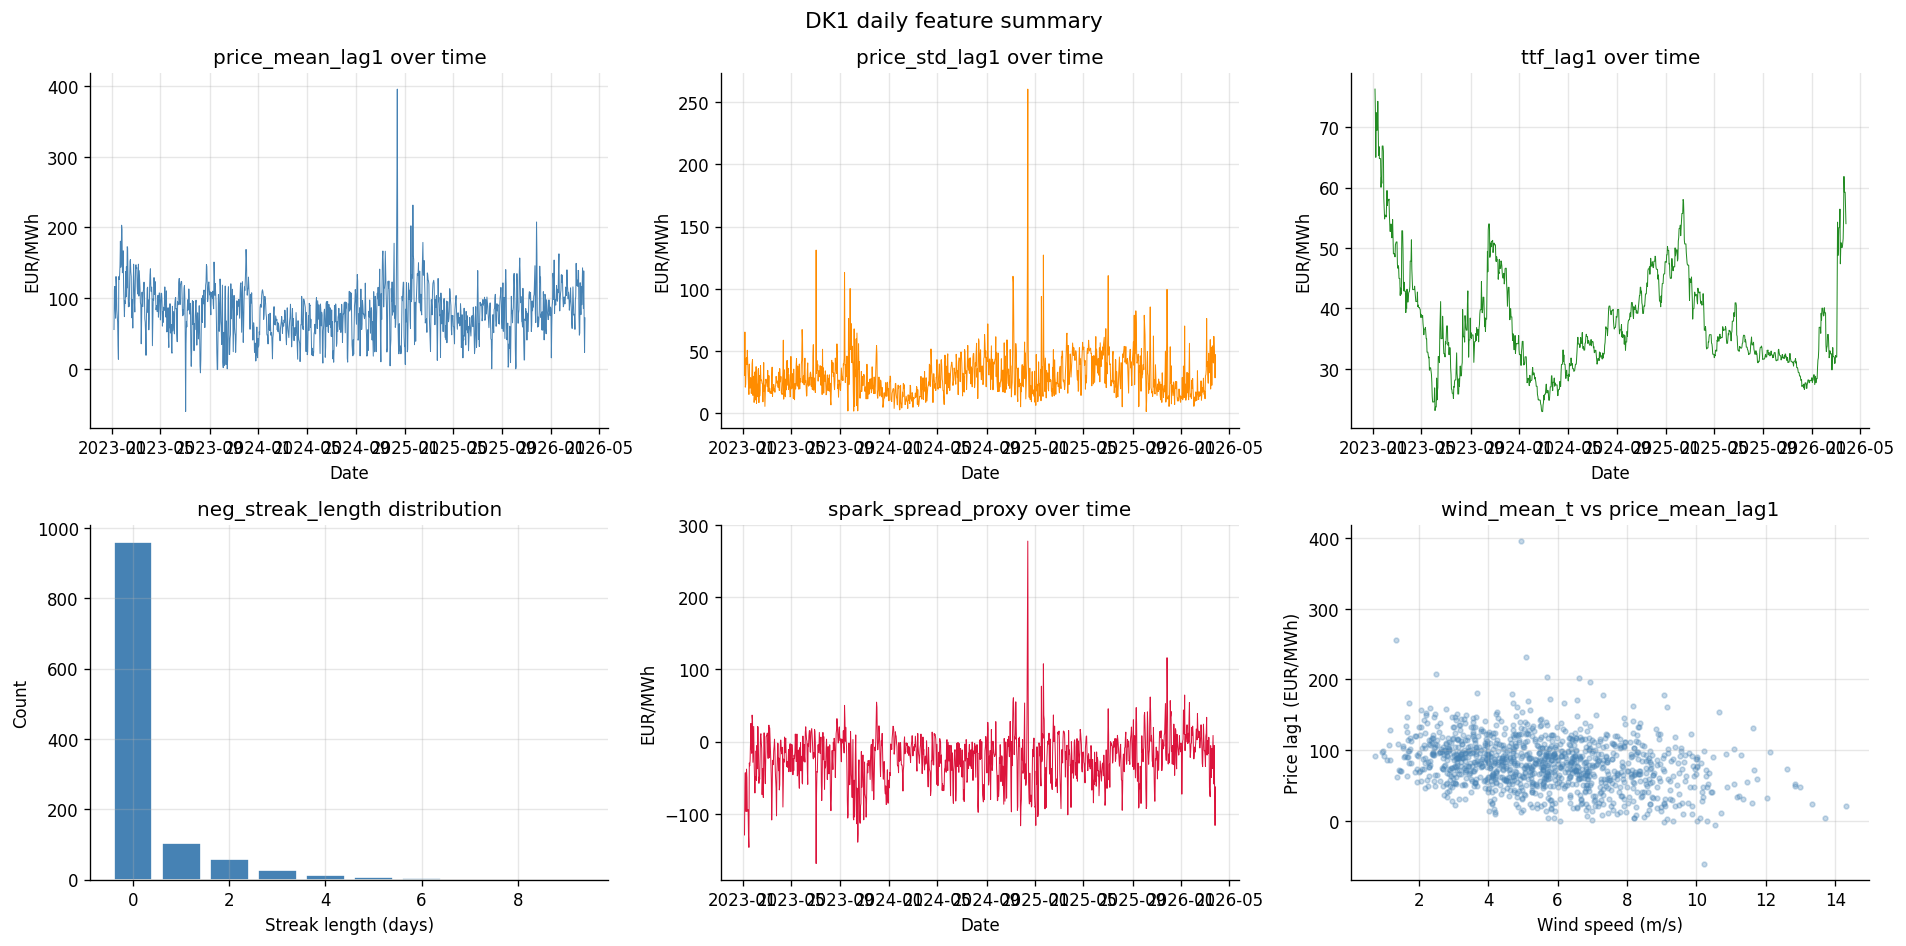

Saved: results/feature_summary.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

ax = axes[0, 0]
ax.plot(df_daily.index, df_daily["price_mean_lag1"], linewidth=0.6, color="steelblue")
ax.set_title("price_mean_lag1 over time"); ax.set_xlabel("Date"); ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(df_daily.index, df_daily["price_std_lag1"], linewidth=0.6, color="darkorange")
ax.set_title("price_std_lag1 over time"); ax.set_xlabel("Date"); ax.set_ylabel("EUR/MWh")
ax.grid(alpha=0.3)

ax = axes[0, 2]
if "ttf_lag1" in df_daily.columns:
    ax.plot(df_daily.index, df_daily["ttf_lag1"], linewidth=0.6, color="forestgreen")
    ax.set_title("ttf_lag1 over time"); ax.set_xlabel("Date"); ax.set_ylabel("EUR/MWh")
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "ttf_lag1 not available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("ttf_lag1 (missing)")

ax = axes[1, 0]
streak_vals = df_daily["neg_streak_length"].value_counts().sort_index()
ax.bar(streak_vals.index, streak_vals.values, color="steelblue", edgecolor="white")
ax.set_title("neg_streak_length distribution")
ax.set_xlabel("Streak length (days)"); ax.set_ylabel("Count"); ax.grid(alpha=0.3)

ax = axes[1, 1]
if "spark_spread_proxy" in df_daily.columns:
    ax.plot(df_daily.index, df_daily["spark_spread_proxy"], linewidth=0.6, color="crimson")
    ax.set_title("spark_spread_proxy over time"); ax.set_xlabel("Date"); ax.set_ylabel("EUR/MWh")
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "spark_spread_proxy not available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("spark_spread_proxy (missing)")

ax = axes[1, 2]
if "wind_mean_t" in df_daily.columns:
    ax.scatter(df_daily["wind_mean_t"], df_daily["price_mean_lag1"],
               alpha=0.3, s=8, color="steelblue")
    ax.set_title("wind_mean_t vs price_mean_lag1")
    ax.set_xlabel("Wind speed (m/s)"); ax.set_ylabel("Price lag1 (EUR/MWh)"); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "wind_mean_t not available", ha="center", va="center", transform=ax.transAxes)

fig.suptitle("DK1 daily feature summary", fontsize=13)
plt.tight_layout()
plt.savefig("results/feature_summary.png", dpi=120)
plt.show()
print("Saved: results/feature_summary.png")


In [15]:
df_daily["price_mean_lag1"]["2024-12-10 00:00:00":]

date
2024-12-10     78.779167
2024-12-11    150.538333
2024-12-12    255.803333
2024-12-13    395.665000
2024-12-14    177.919167
                 ...    
2026-03-23     85.173646
2026-03-24    138.481875
2026-03-25     68.193646
2026-03-26     23.171458
2026-03-27     72.038229
Name: price_mean_lag1, Length: 473, dtype: float64

## Section 3 - Walk-Forward Fold Definitions

### Fold Structure

The pipeline uses an expanding window walk-forward design. Each fold trains on all available history up to its training end date and evaluates on the following calendar year. The training window expands by one year with each fold. The minimum training window is one full calendar year to ensure all seasonal regimes are represented in the initial training set. There is no separate held-out test set - the concatenation of all three out-of-sample fold windows constitutes the evaluation surface and the fold-weighted average WAPE is the reported performance metric.

In [16]:
folds = []
print("Fold  Train start   Train end     Train days   Test start    Test end      Test days")
print("-" * 85)

for i, (tr_start, tr_end, te_start, te_end) in enumerate(config["fold_definitions"]):
    tr_mask = (df_daily.index >= tr_start) & (df_daily.index <= tr_end)
    te_mask = (df_daily.index >= te_start) & (df_daily.index <= te_end)
    tr_days = int(tr_mask.sum())
    te_days = int(te_mask.sum())

    if not (pd.Timestamp(tr_end) < pd.Timestamp(te_start)):
        raise ValueError(f"Fold {i+1}: train_end ({tr_end}) must be before test_start ({te_start})")

    folds.append({
        "fold": i + 1,
        "tr_start": tr_start, "tr_end": tr_end,
        "te_start": te_start, "te_end": te_end,
        "tr_days": tr_days, "te_days": te_days,
        "df_train": df_daily[tr_mask],
        "df_test":  df_daily[te_mask],
    })
    print(f"{i+1:<5} {tr_start:<13} {tr_end:<13} {tr_days:<12} {te_start:<13} {te_end:<13} {te_days}")

# Verify expanding window property.
for i in range(1, len(folds)):
    if folds[i]["tr_days"] <= folds[i-1]["tr_days"]:
        raise ValueError(f"Fold {i+1} training window is not larger than fold {i}")

print("\nAll fold assertions passed.")


Fold  Train start   Train end     Train days   Test start    Test end      Test days
-------------------------------------------------------------------------------------
1     2023-01-01    2023-12-31    361          2024-01-01    2024-12-31    366
2     2023-01-01    2024-12-31    727          2025-01-01    2025-12-31    365
3     2023-01-01    2025-12-31    1092         2026-01-01    2026-04-30    86

All fold assertions passed.


### Fold Regime Preview

Before running any model, it is useful to know the approximate regime distribution each fold's test window will expose the model to. This requires a preliminary Leaf A and Leaf B classification using the full-dataset spike threshold. This is only a rough estimate, not the fold-specific threshold that will be computed inside the walk-forward loop.

In [17]:
# Preliminary threshold from the full hourly series -- preview only.
spike_threshold_preview = np.percentile(
    df_hourly[config["price_col"]].dropna(), config["spike_pct"]
)
print(f"Preliminary spike threshold (p{config["spike_pct"]}): {spike_threshold_preview:.2f} EUR/MWh")

df_daily_preview = build_daily_features(df_hourly, spike_threshold=spike_threshold_preview)

print()
print(f"{"Fold":<5} {"Test period":<28} {"Leaf A %":<12} {"Leaf B %":<12} {"Normal %"}")
print("-" * 65)

for f in folds:
    te_mask = (
        (df_daily_preview.index >= f["te_start"]) &
        (df_daily_preview.index <= f["te_end"])
    )
    te = df_daily_preview[te_mask]
    if len(te) == 0:
        print(f"{f["fold"]:<5} (no test data in preview)")
        continue
    leaf_a = (te["price_neg_frac_lag1"] > 0).sum()
    non_a  = te[te["price_neg_frac_lag1"] == 0]
    leaf_b = (non_a["price_max_lag1"] > spike_threshold_preview).sum()
    normal = len(te) - leaf_a - leaf_b
    period = f"{f["te_start"]} -> {f["te_end"]}"
    print(f"{f["fold"]:<5} {period:<28} {100*leaf_a/len(te):<12.1f} {100*leaf_b/len(te):<12.1f} {100*normal/len(te):.1f}")

# These are preview estimates; fold-specific thresholds computed inside the walk-forward loop will differ slightly.
print("\nNote: regime shares above are preview estimates using the full-dataset threshold.")


Preliminary spike threshold (p95): 154.02 EUR/MWh
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)

Fold  Test period                  Leaf A %     Leaf B %     Normal %
-----------------------------------------------------------------
1     2024-01-01 -> 2024-12-31     21.3         21.3         57.4
2     2025-01-01 -> 2025-12-31     23.6         27.4         49.0
3     2026-01-01 -> 2026-04-30     3.5          36.0         60.5

Note: regime shares above are preview estimates using the full-dataset threshold.


### Save Intermediate Artifacts

df_daily and price_pivot_lag1 are saved here so that later sections and the app can load them without re-running feature engineering.

In [18]:
df_daily.to_csv("models/df_daily_full.csv")
price_pivot_lag1.to_csv("models/price_pivot_lag1_full.csv")

feature_columns = df_daily.columns.tolist()
with open("models/feature_columns.json", "w") as fp:
    json.dump(feature_columns, fp, indent=2)

# Convert non-serialisable fold tuples before saving.
config_save = {k: (str(v) if not isinstance(v, (str, int, float, bool, list, dict, type(None))) else v)
               for k, v in config.items()}
with open("models/config.json", "w") as fp:
    json.dump(config_save, fp, indent=2)

saved_paths = [
    "models/df_daily_full.csv",
    "models/price_pivot_lag1_full.csv",
    "models/feature_columns.json",
    "models/config.json",
]
print("Saved:")
for path in saved_paths:
    size_kb = os.path.getsize(path) / 1024
    print(f"  {path}  ({size_kb:.1f} KB)")


Saved:
  models/df_daily_full.csv  (1429.7 KB)
  models/price_pivot_lag1_full.csv  (189.0 KB)
  models/feature_columns.json  (1.8 KB)
  models/config.json  (1.1 KB)


## Section 4 - The Inner Pipeline Function

This function encapsulates the entire per-fold pipeline. It receives a training window, a test window and the full hourly series and returns predictions and fitted model objects. Nothing inside it reads from or writes to global variables. The walk-forward loop calls it three times, once per fold.

### run_fold() Function

The function is structured as eleven clearly labelled sequential steps covering slicing, threshold computation, feature rebuilding, regime architecture construction, PCA dimensionality reduction, Fuzzy C-Means clustering, regime label assembly, classifier training, expert model training, test prediction and result packaging.

In [19]:
from sklearn.linear_model import Ridge


def run_fold(df_daily_full, price_pivot_full, df_hourly_full, fold_def, cfg):
    """
    Execute the full per-fold modelling pipeline.

    Returns (df_results, models_dict). No global state is read or written.
    df_results columns: date, h00..h23 (actuals), pred_h00..pred_h23, p_A, p_B, p_C0, p_C1.
    """
    tr_start, tr_end, te_start, te_end = fold_def
    pc = cfg["price_col"]

    # ---- STEP 1: Slice train and test windows ----
    tr_mask = (df_daily_full.index >= tr_start) & (df_daily_full.index <= tr_end)
    te_mask = (df_daily_full.index >= te_start) & (df_daily_full.index <= te_end)
    pivot_train = price_pivot_full.reindex(df_daily_full.index[tr_mask])
    pivot_test  = price_pivot_full.reindex(df_daily_full.index[te_mask])
    print(f"  Train: {tr_start} -> {tr_end}  ({tr_mask.sum()} days)")
    print(f"  Test:  {te_start} -> {te_end}  ({te_mask.sum()} days)")

    # ---- STEP 2: Fold-specific spike threshold (training hours only) ----
    h_mask = (
        (df_hourly_full.index >= pd.Timestamp(tr_start, tz="UTC")) &
        (df_hourly_full.index <= pd.Timestamp(tr_end, tz="UTC") + pd.Timedelta(hours=23))
    )
    spike_threshold = float(np.percentile(
        df_hourly_full.loc[h_mask, pc].dropna(), cfg["spike_pct"]
    ))
    print(f"  Spike threshold (fold): {spike_threshold:.2f} EUR/MWh")

    # ---- STEP 3: Rebuild daily features with fold-specific spike_streak_length ----
    # Calling on the full hourly series ensures correct lag initialisation for test dates.
    df_with_spike = build_daily_features(df_hourly_full, spike_threshold=spike_threshold)
    df_train = df_with_spike[(df_with_spike.index >= tr_start) & (df_with_spike.index <= tr_end)].copy()
    df_test  = df_with_spike[(df_with_spike.index >= te_start) & (df_with_spike.index <= te_end)].copy()
    pivot_train = price_pivot_full.reindex(df_train.index)
    pivot_test  = price_pivot_full.reindex(df_test.index)

    # ---- STEP 4: Leaf A and Leaf B masks using actual same-day prices ----
    # Labels for day T must reflect day T's own price behaviour, not day T-1.
    # We derive them from df_hourly_full rather than from the lag-1 feature columns.
    h_copy = df_hourly_full.copy()
    h_copy["_d"] = pd.to_datetime(h_copy.index.normalize().date)
    train_date_set = set(df_train.index.date)
    actual_agg = (
        h_copy[h_copy["_d"].dt.date.isin(train_date_set)]
        .groupby("_d")[pc]
        .agg(neg_frac=lambda x: (x < 0).mean(), day_max="max")
    )
    actual_agg.index = pd.to_datetime(actual_agg.index)
    actual_agg = actual_agg.reindex(df_train.index)

    mask_A      = actual_agg["neg_frac"] > 0.15
    mask_B      = (~mask_A) & (actual_agg["day_max"] > spike_threshold)
    mask_normal = ~mask_A & ~mask_B

    n_total = len(df_train)
    use_ridge_regime = set()
    for label, mask, name in [(0, mask_A, "Leaf A"), (1, mask_B, "Leaf B"), (2, mask_normal, "Normal")]:
        n = int(mask.sum())
        line = f"  {name}: {n} days ({100*n/n_total:.1f}%)"
        if n < cfg["min_cluster_size"]:
            line += " -- WARNING: small bucket, Ridge fallback for expert models"
            use_ridge_regime.update({label, label + 1} if label == 2 else {label})
        print(line)

    # ---- STEP 5: PCA feature matrix for normal training days ----
    pca_exclude = {
        "price_neg_frac_lag1", "was_negative_lag1", "neg_streak_length",
        "price_max_lag1", "spike_streak_length",
    }
    pca_cols = [c for c in df_train.columns if c not in pca_exclude]

    normal_idx   = df_train.index[mask_normal.values]
    X_daily_norm = df_train.loc[normal_idx, pca_cols].values
    X_pivot_norm = pivot_train.reindex(normal_idx).values

    # First row of pivot may be NaN (lag-1 shift at start of training window).
    valid = ~np.isnan(X_pivot_norm).any(axis=1)
    X_daily_norm    = X_daily_norm[valid]
    X_pivot_norm    = X_pivot_norm[valid]
    normal_idx_valid = normal_idx[valid]

    X_combined = np.hstack([X_daily_norm, X_pivot_norm])
    scaler_pca = StandardScaler()
    X_scaled   = scaler_pca.fit_transform(X_combined)

    pca_probe = PCA(random_state=cfg["random_seed"])
    pca_probe.fit(X_scaled)
    cumvar  = np.cumsum(pca_probe.explained_variance_ratio_)
    n_comp  = int(np.searchsorted(cumvar, cfg["pca_variance_target"])) + 1
    n_comp  = min(n_comp, X_scaled.shape[1], X_scaled.shape[0] - 1)
    print(f"  PCA: {n_comp} components retain {cumvar[n_comp-1]:.3f} cumulative variance")

    pca_fit = PCA(n_components=n_comp, random_state=cfg["random_seed"])
    X_pca   = pca_fit.fit_transform(X_scaled)


    # ---- STEP 6: FKM on normal training days ----
    np.random.seed(cfg["random_seed"])
    cntr, u, _, _, _, _, _ = fuzz.cmeans(
        X_pca.T, c=cfg["fkm_k_normal"], m=cfg["fkm_m"],
        error=cfg["fkm_error"], maxiter=cfg["fkm_maxiter"], seed=cfg["random_seed"]
    )
    hard_labels_normal = np.argmax(u, axis=0)

    for k in range(cfg["fkm_k_normal"]):
        n_k = int((hard_labels_normal == k).sum())
        warn = " -- WARNING: small cluster" if n_k < cfg["min_cluster_size"] else ""
        print(f"  FKM C{k}: {n_k} days{warn}")

    # ---- STEP 7: Assemble regime labels for all training days ----
    regime_labels = pd.Series(np.nan, index=df_train.index, dtype=float)
    regime_labels.loc[df_train.index[mask_A.values]]  = 0
    regime_labels.loc[df_train.index[mask_B.values]]  = 1
    for pos, d in enumerate(normal_idx_valid):
        regime_labels.loc[d] = 2 + int(hard_labels_normal[pos])
    # Normal days excluded from PCA (first-row NaN in pivot) → assign to C0.
    still_nan = regime_labels.isna() & mask_normal.values
    regime_labels.loc[regime_labels.index[still_nan]] = 2
    assert regime_labels.isna().sum() == 0, "Unassigned regime labels remain."
    regime_labels = regime_labels.astype(int)

    # ---- STEP 8: Multinomial regime classifier ----

    
    # Augment df_train and df_test with pivot hours so the classifier
    # sees the same yesterday-price-curve signal that defined C0/C1 in FKM.
    _pivot_tr = pivot_train.copy()
    # _pivot_tr.columns = [f"pivot_h{h:02d}" for h in range(24)]
    _pivot_te = pivot_test.copy()
    #_pivot_te.columns = [f"pivot_h{h:02d}" for h in range(24)]

    df_train_clf = pd.concat([df_train, _pivot_tr], axis=1).dropna()
    df_test_clf  = pd.concat([df_test,  _pivot_te], axis=1).dropna()

    clf_cols = df_train_clf.columns.tolist()
    X_clf    = df_train_clf[clf_cols].values
    y_clf    = regime_labels.reindex(df_train_clf.index).values

    clf = XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=cfg["random_seed"],
        verbosity=0,
        **cfg.get("clf_params", {}),
    )
    clf.fit(X_clf, y_clf)
    print(f"  Classifier training accuracy: {(clf.predict(X_clf) == y_clf).mean():.3f}")

    # ---- STEP 9: 96 expert models (4 regimes × 24 hours) ----
    # Build a (date × hour) price matrix for target extraction.
    h2 = df_hourly_full.copy()
    h2["_d"] = pd.to_datetime(h2.index.normalize().date)
    h2["_h"] = h2.index.hour
    price_mat = h2.pivot_table(index="_d", columns="_h", values=pc, aggfunc="mean")
    price_mat.index   = pd.to_datetime(price_mat.index)
    price_mat.columns = list(range(24))

    expert_models = {r: {} for r in range(4)}
    reg_params    = cfg.get("reg_params", {})

    for regime in range(4):
        r_dates = df_train_clf.index[regime_labels.values == regime]
        r_dates_clf = r_dates[r_dates.isin(df_train_clf.index)]
        X_reg   = df_train_clf.loc[r_dates_clf, clf_cols].values
        Y_reg   = price_mat.reindex(r_dates).values  # (n_days, 24)
        for hour in range(24):
            y_h   = Y_reg[:, hour]
            valid = ~np.isnan(y_h)
            if regime in use_ridge_regime:
                mdl = Ridge()
            else:
                mdl = XGBRegressor(random_state=cfg["random_seed"], verbosity=0, **reg_params)
            mdl.fit(X_reg[valid], y_h[valid])
            expert_models[regime][hour] = mdl

    print("  Expert models trained: 96")

    # ---- STEP 10: Predict on test window ----
    X_test_mat    = df_test_clf[clf_cols].values
    regime_probs  = clf.predict_proba(X_test_mat)     # (n_test, 4)

    results_rows = []
    for i, date in enumerate(df_test_clf.index):
        probs = regime_probs[i]
        x_row = X_test_mat[i : i + 1]

        # 24-element forecast from each regime expert, then weighted sum.
        regime_preds = np.array([
            [expert_models[r][h].predict(x_row)[0] for h in range(24)]
            for r in range(4)
        ])                                             # (4, 24)
        y_hat = (probs[:, None] * regime_preds).sum(axis=0)

        act = price_mat.loc[date].values if date in price_mat.index else np.full(24, np.nan)

        row = {"date": date}
        for h in range(24):
            row[f"h{h:02d}"]      = act[h]
            row[f"pred_h{h:02d}"] = y_hat[h]
        row.update(p_A=probs[0], p_B=probs[1], p_C0=probs[2], p_C1=probs[3])
        results_rows.append(row)

    # ---- STEP 11: Package and return ----
    df_results  = pd.DataFrame(results_rows)
    models_dict = {
        "scaler_pca":      scaler_pca,
        "pca":             pca_fit,
        "cntr":            cntr,
        "spike_threshold": spike_threshold,
        "classifier":      clf,
        "expert_models":   expert_models,
        "clf_feature_cols": clf_cols,
    }

    return df_results, models_dict


### Dry Run on Fold 1

Before running all folds the function is verified on fold 1 alone to catch errors.

In [20]:
print("=== Dry run: fold 1 ===")
df_results_fold1, models_fold1 = run_fold(
    df_daily, price_pivot_lag1, df_hourly,
    config["fold_definitions"][0], config
)

print(f"\nResult shape: {df_results_fold1.shape}")
print("First 5 rows:")
print(df_results_fold1.head().to_string())

pred_cols = [c for c in df_results_fold1.columns if c.startswith("pred_")]
assert df_results_fold1[pred_cols].isna().sum().sum() == 0, "NaN in predictions"
print("\nFold 1 dry run passed.")


=== Dry run: fold 1 ===
  Train: 2023-01-01 -> 2023-12-31  (361 days)
  Test:  2024-01-01 -> 2024-12-31  (366 days)
  Spike threshold (fold): 161.78 EUR/MWh
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
  Leaf A: 31 days (8.6%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 100 days (27.7%)
  Normal: 230 days (63.7%)
  PCA: 17 components retain 0.883 cumulative variance
  FKM C0: 118 days
  FKM C1: 112 days
  Classifier training accuracy: 0.983
  Expert models trained: 96

Result shape: (366, 53)
First 5 rows:
        date    h00   pred_h00    h01   pred_h01    h02   pred_h02    h03   pred_h03    h04   pred_h04    h05    pred_h05    h06    pred_h06    h07    pred_h07    h08    pred_h08    h09    pred_h09    h10    pred_h10    h11   pred_h11    h12   pred_h12    h13   pred_h13     h14   pred_h14     h15   pred_h15     h16    pred_h16     h17    pred_h17     h18   pred_h18     h19   pred_h19     h20   pred_h20    h21   pred_h21    

In [21]:
# 1. Run your pipeline fold
df_results_fold1, models_fold1 = run_fold(
    df_daily, price_pivot_lag1, df_hourly,
    config["fold_definitions"][0], config
)

# 2. Extract PCA loadings right after (Separate from the function)
# Reconstruct the exact column alignment used inside Step 5
pca_exclude = {
    "price_neg_frac_lag1", "was_negative_lag1", "neg_streak_length",
    "price_max_lag1", "spike_streak_length",
}
pca_cols = [c for c in df_daily.columns if c not in pca_exclude]
pivot_cols = [f"pivot_hour_{h}" for h in price_pivot_lag1.columns]
all_combined_cols = pca_cols + pivot_cols

# Pull out components matrix
loadings = models_fold1["pca"].components_

# Convert to structured DataFrame
df_loadings = pd.DataFrame(
    loadings,
    columns=all_combined_cols,
    index=[f"PC_{i+1}" for i in range(loadings.shape[0])]
).T

# 3. Analyze or Save
df_loadings.to_csv(f"pca_loadings_fold_.csv") # Using test start date as ID

df_loadings

  Train: 2023-01-01 -> 2023-12-31  (361 days)
  Test:  2024-01-01 -> 2024-12-31  (366 days)
  Spike threshold (fold): 161.78 EUR/MWh
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
  Leaf A: 31 days (8.6%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 100 days (27.7%)
  Normal: 230 days (63.7%)
  PCA: 17 components retain 0.883 cumulative variance
  FKM C0: 118 days
  FKM C1: 112 days
  Classifier training accuracy: 0.983
  Expert models trained: 96


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17
price_mean_lag1,-0.039603,0.214012,-0.057359,-0.027032,0.003461,0.012950,-0.018974,-0.032323,-0.022055,-0.009674,-0.006294,-0.010769,0.014853,0.014112,-0.008944,0.000629,0.007454
price_std_lag1,-0.028886,-0.042745,0.014195,-0.185147,-0.079372,-0.011161,-0.221077,-0.207897,0.277137,-0.143188,-0.155453,-0.084741,-0.048242,0.019434,0.179282,0.151260,-0.041823
price_min_lag1,-0.029415,0.189260,-0.036540,0.028447,0.028841,0.021361,0.074129,0.061584,-0.191519,0.022356,0.115196,0.015654,-0.016565,-0.013192,-0.081805,-0.041443,0.046134
price_range_lag1,-0.031627,-0.028157,-0.005170,-0.182351,-0.080861,-0.011409,-0.177930,-0.260657,0.278079,-0.126630,-0.137508,-0.127574,-0.026430,0.039436,0.226676,0.168944,-0.026561
pivot_hour_peak_lag1,-0.089268,-0.057942,0.081223,-0.108764,0.064485,-0.026842,-0.154735,0.018459,-0.135121,0.248255,-0.006101,0.107421,-0.142850,0.036199,-0.069041,-0.094444,0.135839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pivot_hour_h19,-0.106676,0.127150,-0.052453,-0.136943,0.009214,-0.023258,-0.171242,0.025580,0.020956,0.030569,0.008503,0.031790,-0.014180,-0.055610,-0.110739,0.037209,-0.021412
pivot_hour_h20,-0.103118,0.131366,-0.051390,-0.132510,0.016065,-0.038647,-0.172706,0.044166,0.030222,0.044591,0.032010,0.015524,0.000973,-0.060627,-0.145367,0.024004,-0.041554
pivot_hour_h21,-0.096354,0.137046,-0.034703,-0.119065,0.029229,-0.050844,-0.177743,0.078703,0.047997,0.050526,0.020174,0.023491,0.001623,-0.050351,-0.149600,0.038821,-0.054210
pivot_hour_h22,-0.100620,0.120064,-0.043565,-0.114027,0.020634,-0.059471,-0.170527,0.104080,0.026741,0.033554,0.029015,0.018537,0.035207,-0.066391,-0.120921,0.059942,-0.052448


## Section 5 - Walk-Forward Execution

The loop runs run_fold for all three folds, collecting results into a single prediction dataframe that spans the full evaluation period. Each fold's models are stored separately in case post-hoc analysis requires inspecting fold-specific objects.

### Execute Loop

In [22]:
all_results = []
all_models  = []

for i, fold_def in enumerate(config["fold_definitions"]):
    print(f"\n{'='*55}")
    print(f"Fold {i+1} of {len(config['fold_definitions'])}")
    results, models = run_fold(
        df_daily, price_pivot_lag1, df_hourly, fold_def, config
    )
    all_results.append(results)
    all_models.append(models)
    print(f"Fold {i+1} complete -- {len(results)} test days predicted")

df_predictions = pd.concat(all_results, ignore_index=True)
df_predictions = df_predictions.sort_values("date").reset_index(drop=True)

print(f"\nTotal predicted days: {len(df_predictions)}")
print(f"Date range: {df_predictions['date'].min()} -> {df_predictions['date'].max()}")
df_predictions.to_csv("results/walk_forward_predictions.csv", index=False)
print("Saved: results/walk_forward_predictions.csv")



Fold 1 of 3
  Train: 2023-01-01 -> 2023-12-31  (361 days)
  Test:  2024-01-01 -> 2024-12-31  (366 days)
  Spike threshold (fold): 161.78 EUR/MWh
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
  Leaf A: 31 days (8.6%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 100 days (27.7%)
  Normal: 230 days (63.7%)
  PCA: 17 components retain 0.883 cumulative variance
  FKM C0: 118 days
  FKM C1: 112 days
  Classifier training accuracy: 0.983
  Expert models trained: 96
Fold 1 complete -- 366 test days predicted

Fold 2 of 3
  Train: 2023-01-01 -> 2024-12-31  (727 days)
  Test:  2025-01-01 -> 2025-12-31  (365 days)
  Spike threshold (fold): 152.89 EUR/MWh
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
  Leaf A: 78 days (10.7%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 208 days (28.6%)
  Normal: 441 days (60.7%)
  PCA: 18 components retain 0.881 cumulative variance
  FKM C0: 220 

## Section 6 - Evaluation

Performance is reported at four levels: overall, per regime, per hour of day, and per fold, because the aggregate WAPE obscures where the model fails. Naive baselines are computed for every test day and included in every comparison. For Regime A, MAE replaces WAPE because near-zero and negative prices make WAPE unstable.

### Naive Baselines

Two baselines are added to df_predictions. Naive 1 repeats yesterday's observed 24-hour price curve. Naive 2 averages the same 24-hour slots across the preceding seven days.

In [23]:
# Build full price-by-hour lookup from df_hourly.
_h = df_hourly.copy()
_h["_d"] = pd.to_datetime(_h.index.normalize().date)
_h["_hr"] = _h.index.hour
price_mat_eval = _h.pivot_table(index="_d", columns="_hr", values=config["price_col"], aggfunc="mean")
price_mat_eval.index   = pd.to_datetime(price_mat_eval.index)
price_mat_eval.columns = list(range(24))

naive1_arr = np.full((len(df_predictions), 24), np.nan)
naive2_arr = np.full((len(df_predictions), 24), np.nan)

for i, date in enumerate(pd.to_datetime(df_predictions["date"])):
    prev1 = date - pd.Timedelta(days=1)
    if prev1 in price_mat_eval.index:
        naive1_arr[i] = price_mat_eval.loc[prev1].values

    window = pd.date_range(end=date - pd.Timedelta(days=1), periods=7, freq="D")
    valid_w = [d for d in window if d in price_mat_eval.index]
    if valid_w:
        naive2_arr[i] = price_mat_eval.loc[valid_w].mean(axis=0).values

for h in range(24):
    df_predictions[f"naive1_h{h:02d}"] = naive1_arr[:, h]
    df_predictions[f"naive2_h{h:02d}"] = naive2_arr[:, h]

n1_valid = (~np.isnan(naive1_arr).any(axis=1)).sum()
n2_valid = (~np.isnan(naive2_arr).any(axis=1)).sum()
print(f"Valid naive 1 forecasts: {n1_valid} / {len(df_predictions)}")
print(f"Valid naive 2 forecasts: {n2_valid} / {len(df_predictions)}")


Valid naive 1 forecasts: 817 / 817
Valid naive 2 forecasts: 817 / 817


### Overall Metrics

WAPE and MAE are computed over all test hours by flattening the full prediction matrix. NaN values (arising from test days with missing actual prices) are excluded.

In [24]:
hour_cols  = [f"h{h:02d}"      for h in range(24)]
pred_cols  = [f"pred_h{h:02d}" for h in range(24)]
n1_cols    = [f"naive1_h{h:02d}" for h in range(24)]
n2_cols    = [f"naive2_h{h:02d}" for h in range(24)]


def wape(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    denom = np.abs(a).sum()
    return 100 * np.abs(a - p).sum() / denom if denom > 0 else np.nan


def mae(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    return np.abs(a - p).mean() if len(a) > 0 else np.nan


act_flat  = df_predictions[hour_cols].values.ravel()
pred_flat = df_predictions[pred_cols].values.ravel()
n1_flat   = df_predictions[n1_cols].values.ravel()
n2_flat   = df_predictions[n2_cols].values.ravel()

print("=== Overall Metrics ===")
print(f"{'Metric':<12} {'Model':>10} {'Naive 1':>10} {'Naive 2':>10}")
print("-" * 45)
print(f"{'WAPE (%)':<12} {wape(act_flat, pred_flat):>10.2f} {wape(act_flat, n1_flat):>10.2f} {wape(act_flat, n2_flat):>10.2f}")
print(f"{'MAE':<12} {mae(act_flat, pred_flat):>10.2f} {mae(act_flat, n1_flat):>10.2f} {mae(act_flat, n2_flat):>10.2f}")


=== Overall Metrics ===
Metric            Model    Naive 1    Naive 2
---------------------------------------------
WAPE (%)          25.74      36.54      38.35
MAE               20.30      28.81      30.23


### Regime-Level Metrics

Each test day is assigned a dominant regime label as the argmax of its four probability columns. WAPE is suppressed for Regime A (negative-price days) because near-zero or negative denominators make WAPE undefined or misleading.

In [25]:
prob_cols = ["p_A", "p_B", "p_C0", "p_C1"]
regime_names = {0: "Leaf A (negative)", 1: "Leaf B (spike)", 2: "C0 (normal)", 3: "C1 (normal)"}
df_predictions["dominant_regime"] = df_predictions[prob_cols].values.argmax(axis=1)

print("=== Regime-Level Metrics ===")
print(f"{'Regime':<20} {'N':>5} {'Share%':>8} {'WAPE%':>10} {'MAE':>8} {'N1 WAPE%':>10} {'N2 WAPE%':>10}")
print("-" * 80)

for label in range(4):
    mask = df_predictions["dominant_regime"] == label
    grp  = df_predictions[mask]
    if len(grp) == 0:
        print(f"{regime_names[label]:<20} {'(empty)':>5}")
        continue
    a  = grp[hour_cols].values.ravel()
    p  = grp[pred_cols].values.ravel()
    n1 = grp[n1_cols].values.ravel()
    n2 = grp[n2_cols].values.ravel()
    share = 100 * len(grp) / len(df_predictions)
    mae_v = mae(a, p)
    if label == 0:
        print(f"{regime_names[label]:<20} {len(grp):>5} {share:>8.1f} {'(MAE only)':>10} {mae_v:>8.2f} {'--':>10} {'--':>10}")
        print("  Note: WAPE suppressed for Regime A -- near-zero/negative price denominators.")
    else:
        print(f"{regime_names[label]:<20} {len(grp):>5} {share:>8.1f} {wape(a, p):>10.2f} {mae_v:>8.2f} {wape(a, n1):>10.2f} {wape(a, n2):>10.2f}")


=== Regime-Level Metrics ===
Regime                   N   Share%      WAPE%      MAE   N1 WAPE%   N2 WAPE%
--------------------------------------------------------------------------------
Leaf A (negative)       49      6.0 (MAE only)    36.12         --         --
  Note: WAPE suppressed for Regime A -- near-zero/negative price denominators.
Leaf B (spike)         194     23.7      20.75    22.62      31.08      31.59
C0 (normal)            297     36.4      22.81    17.46      36.09      36.13
C1 (normal)            277     33.9      27.83    18.91      38.42      41.52


### Hourly Metrics

MAE and mean signed error are computed per hour of day to reveal systematic intraday bias patterns.

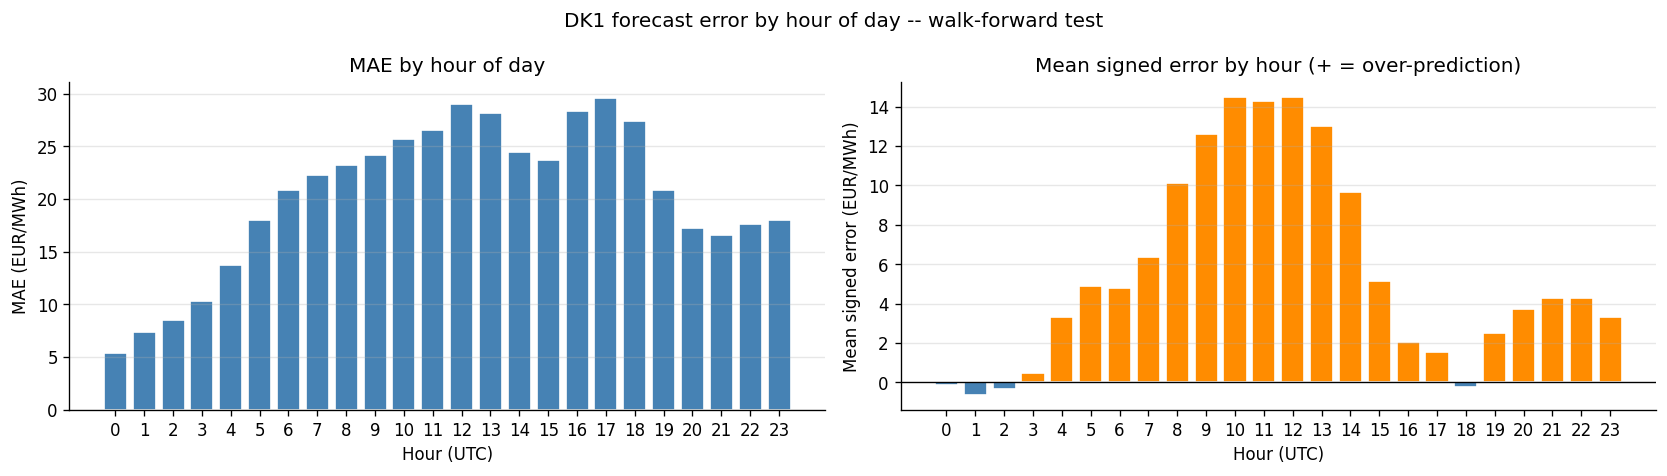

Saved: results/hourly_errors.png
Hours with highest MAE: ['h17 (29.63)', 'h12 (29.03)', 'h16 (28.37)']


In [26]:
mae_by_hour  = np.zeros(24)
bias_by_hour = np.zeros(24)

for h in range(24):
    a = df_predictions[f"h{h:02d}"].values
    p = df_predictions[f"pred_h{h:02d}"].values
    mask = ~(np.isnan(a) | np.isnan(p))
    mae_by_hour[h]  = np.abs(a[mask] - p[mask]).mean()
    bias_by_hour[h] = (p[mask] - a[mask]).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(range(24), mae_by_hour, color="steelblue", edgecolor="white")
ax1.set_title("MAE by hour of day")
ax1.set_xlabel("Hour (UTC)"); ax1.set_ylabel("MAE (EUR/MWh)")
ax1.set_xticks(range(24)); ax1.grid(axis="y", alpha=0.3)

colors = ["darkorange" if b > 0 else "steelblue" for b in bias_by_hour]
ax2.bar(range(24), bias_by_hour, color=colors, edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Mean signed error by hour (+ = over-prediction)")
ax2.set_xlabel("Hour (UTC)"); ax2.set_ylabel("Mean signed error (EUR/MWh)")
ax2.set_xticks(range(24)); ax2.grid(axis="y", alpha=0.3)

fig.suptitle("DK1 forecast error by hour of day -- walk-forward test", fontsize=12)
plt.tight_layout()
plt.savefig("results/hourly_errors.png", dpi=120)
plt.show()
print("Saved: results/hourly_errors.png")

top3 = np.argsort(mae_by_hour)[-3:][::-1]
print(f"Hours with highest MAE: {[f'h{h:02d} ({mae_by_hour[h]:.2f})' for h in top3]}")


### Fold-Level Metrics

Tagging each prediction by fold number allows detection of distribution shift across time: if a later fold shows substantially worse WAPE relative to the naive baseline, it suggests the training regime mix no longer matches the test period.

In [27]:
fold_tags = np.zeros(len(df_predictions), dtype=int)
for i, (_, _, te_start, te_end) in enumerate(config["fold_definitions"]):
    mask = (
        (pd.to_datetime(df_predictions["date"]) >= te_start) &
        (pd.to_datetime(df_predictions["date"]) <= te_end)
    )
    fold_tags[mask] = i + 1
df_predictions["fold"] = fold_tags

print("=== Fold-Level Metrics ===")
print(f"{'Fold':<6} {'N':>5} {'Test period':<25} {'WAPE% model':>12} {'WAPE% N1':>10} {'WAPE% N2':>10}")
print("-" * 75)

for i, (_, _, te_start, te_end) in enumerate(config["fold_definitions"]):
    grp = df_predictions[df_predictions["fold"] == i + 1]
    if len(grp) == 0:
        continue
    a   = grp[hour_cols].values.ravel()
    p   = grp[pred_cols].values.ravel()
    n1  = grp[n1_cols].values.ravel()
    n2  = grp[n2_cols].values.ravel()
    wm  = wape(a, p)
    wn1 = wape(a, n1)
    wn2 = wape(a, n2)
    period = f"{te_start} -> {te_end}"
    print(f"{i+1:<6} {len(grp):>5} {period:<25} {wm:>12.2f} {wn1:>10.2f} {wn2:>10.2f}")
    if wm > wn1 and wm > wn2:
        print(f"  WARNING: fold {i+1} model WAPE exceeds both naive baselines.")

# Save final predictions with naive baselines appended.
df_predictions.to_csv("results/walk_forward_predictions_final.csv", index=False)
size_kb = os.path.getsize("results/walk_forward_predictions_final.csv") / 1024
print(f"\nSaved: results/walk_forward_predictions_final.csv  ({size_kb:.1f} KB)")
print(f"Columns: {df_predictions.shape[1]}  |  Rows: {len(df_predictions)}")


=== Fold-Level Metrics ===
Fold       N Test period                WAPE% model   WAPE% N1   WAPE% N2
---------------------------------------------------------------------------
1        366 2024-01-01 -> 2024-12-31         29.70      40.66      43.58
2        365 2025-01-01 -> 2025-12-31         25.02      35.77      37.60
3         86 2026-01-01 -> 2026-04-30         16.35      26.81      25.21

Saved: results/walk_forward_predictions_final.csv  (979.2 KB)
Columns: 103  |  Rows: 817


## Section 7 - Model Diagnostics

Four diagnostic views examine where and why the model succeeds or fails: a time series overlay coloured by regime, the average 24-hour price curve per regime, the full distribution of prediction errors, and the trajectory of regime probabilities over the test period.

### Actual vs Predicted Daily Mean Price

The daily mean price collapses the 24-hour forecast to one number per day and makes systematic over- or under-prediction visible. The regime strip below the main panel shows the dominant regime assigned by the classifier on each test day.

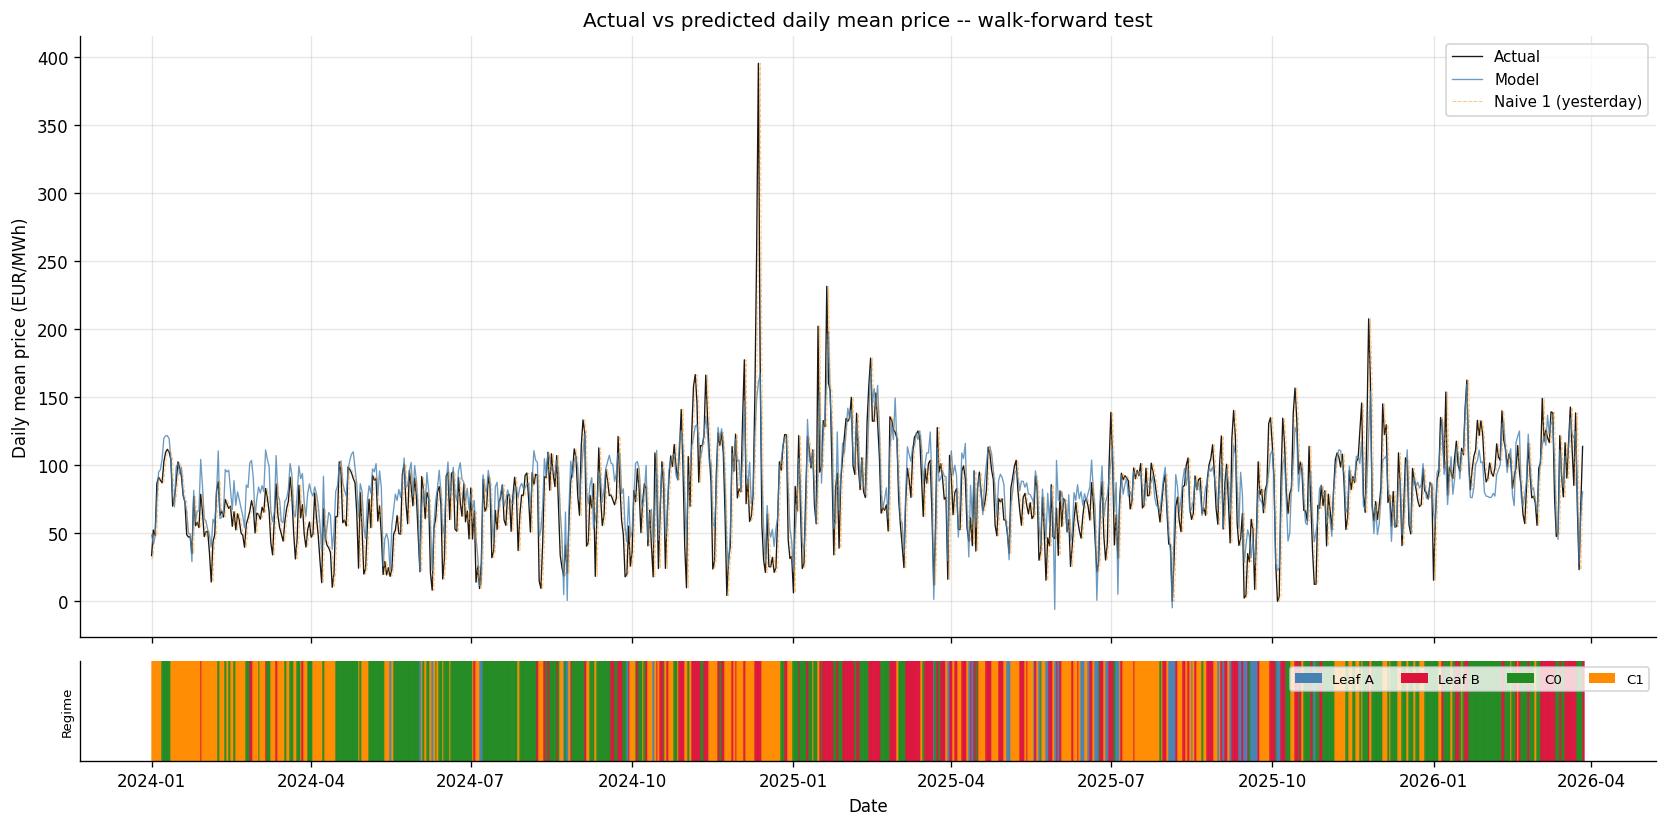

Saved: results/timeseries_actual_vs_predicted.png


In [28]:
from matplotlib.patches import Patch

df_predictions["actual_mean"] = df_predictions[hour_cols].mean(axis=1)
df_predictions["pred_mean"]   = df_predictions[pred_cols].mean(axis=1)
df_predictions["naive1_mean"] = df_predictions[n1_cols].mean(axis=1)

dates = pd.to_datetime(df_predictions["date"])
regime_colors = {0: "steelblue", 1: "crimson", 2: "forestgreen", 3: "darkorange"}
regime_labels_plot = {0: "Leaf A", 1: "Leaf B", 2: "C0", 3: "C1"}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7),
    gridspec_kw={"height_ratios": [6, 1]}, sharex=True
)

ax1.plot(dates, df_predictions["actual_mean"],
         color="black", linewidth=0.8, label="Actual", alpha=0.9)
ax1.plot(dates, df_predictions["pred_mean"],
         color="steelblue", linewidth=0.8, label="Model", alpha=0.8)
ax1.plot(dates, df_predictions["naive1_mean"],
         color="darkorange", linewidth=0.6, label="Naive 1 (yesterday)",
         alpha=0.5, linestyle="--")
ax1.set_ylabel("Daily mean price (EUR/MWh)")
ax1.set_title("Actual vs predicted daily mean price -- walk-forward test")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Colour each day in the strip by its dominant regime.
for _, row in df_predictions.iterrows():
    d = pd.to_datetime(row["date"])
    ax2.axvspan(d, d + pd.Timedelta(days=1),
               color=regime_colors[row["dominant_regime"]], alpha=0.8)
ax2.set_yticks([])
ax2.set_ylabel("Regime", fontsize=8)
ax2.set_xlabel("Date")
legend_patches = [Patch(facecolor=regime_colors[l], label=regime_labels_plot[l])
                  for l in range(4)]
ax2.legend(handles=legend_patches, loc="upper right", ncol=4, fontsize=8)

plt.tight_layout()
plt.savefig("results/timeseries_actual_vs_predicted.png", dpi=120)
plt.show()
print("Saved: results/timeseries_actual_vs_predicted.png")


### Average 24-Hour Profile per Regime

Comparing the mean actual curve against the mean predicted curve within each regime reveals whether the expert models have learned the correct intraday shape. A systematic offset across all hours points to a level bias; a shape mismatch at specific hours points to a structural deficiency in the features available for those periods.

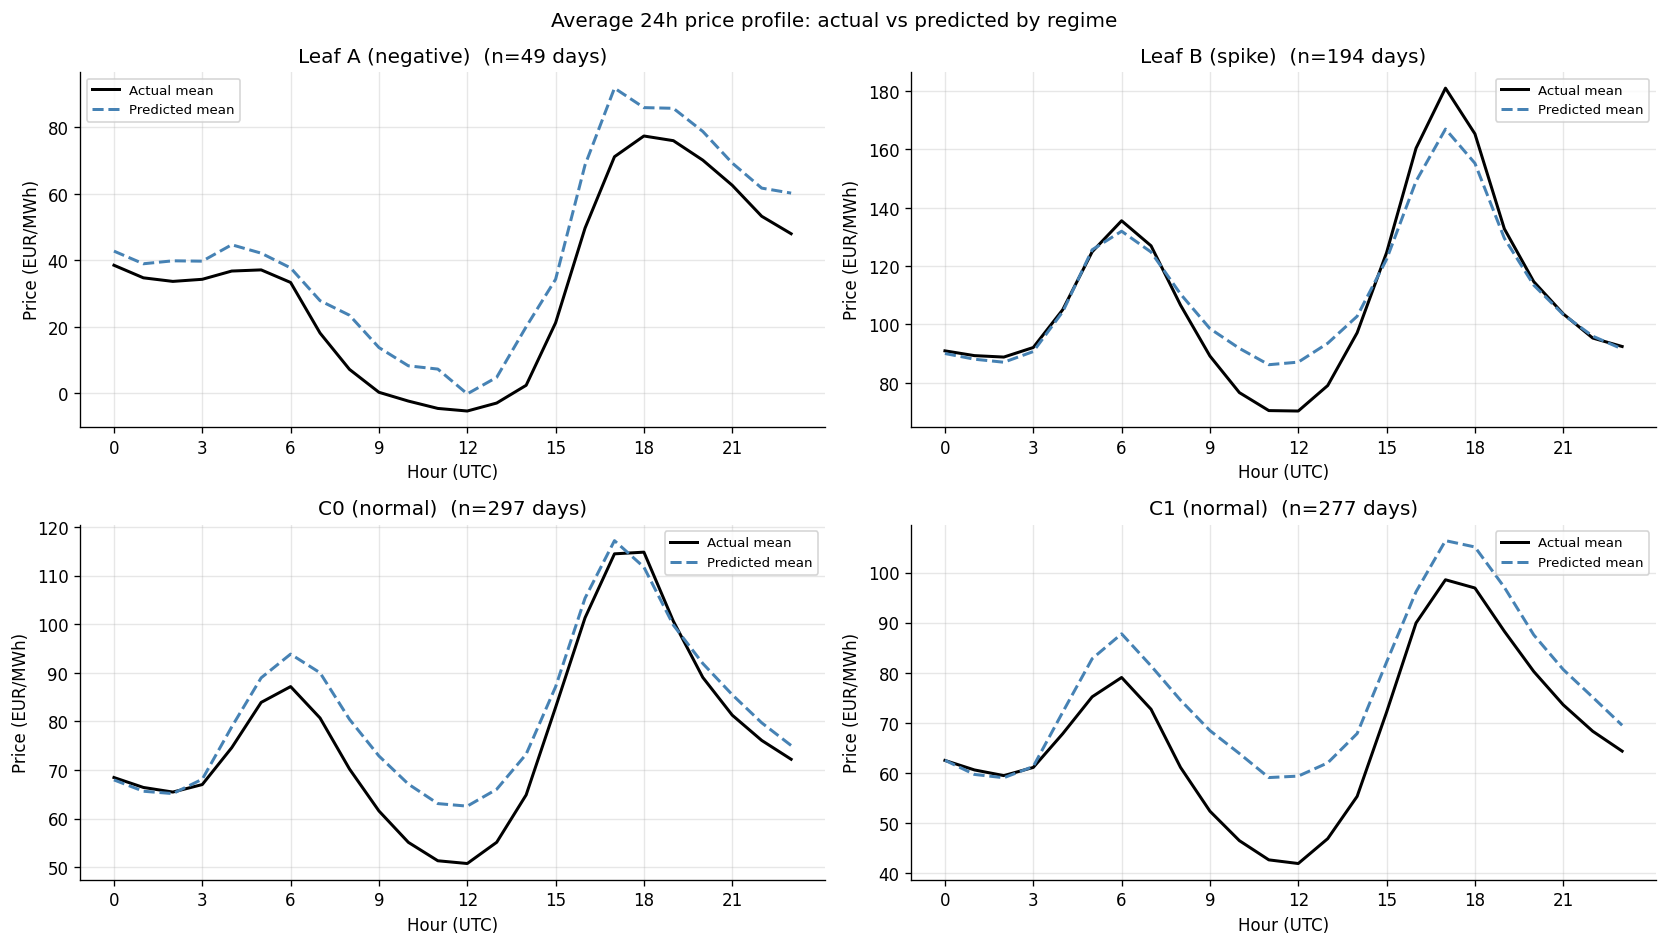

Saved: results/regime_profiles_actual_vs_predicted.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
hours = list(range(24))

for idx in range(4):
    ax   = axes[idx]
    name = regime_names[idx]
    mask = df_predictions["dominant_regime"] == idx
    grp  = df_predictions[mask]

    if len(grp) == 0:
        ax.text(0.5, 0.5, "No test days", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(name)
        continue

    act_mean = grp[hour_cols].mean(axis=0).values
    prd_mean = grp[pred_cols].mean(axis=0).values
    # act_std  = grp[hour_cols].std(axis=0).values

    # ax.fill_between(hours, act_mean - act_std, act_mean + act_std,
    #                 color="black", alpha=0.08, label="Actual +/-1 std")
    ax.plot(hours, act_mean, color="black", linewidth=1.8, label="Actual mean")
    ax.plot(hours, prd_mean, color="steelblue", linewidth=1.8,
            linestyle="--", label="Predicted mean")
    ax.set_title(f"{name}  (n={len(grp)} days)")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Price (EUR/MWh)")
    ax.legend(fontsize=8)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(alpha=0.3)

fig.suptitle("Average 24h price profile: actual vs predicted by regime", fontsize=12)
plt.tight_layout()
plt.savefig("results/regime_profiles_actual_vs_predicted.png", dpi=120)
plt.show()
print("Saved: results/regime_profiles_actual_vs_predicted.png")


### Error Distribution and Rolling WAPE

The error histogram shows whether prediction mistakes are symmetric around zero (no bias) or skewed (systematic over- or under-prediction). The rolling 30-day WAPE reveals whether accuracy is stable over time or degrades in specific periods, which can indicate a regime shift the model has not adapted to.

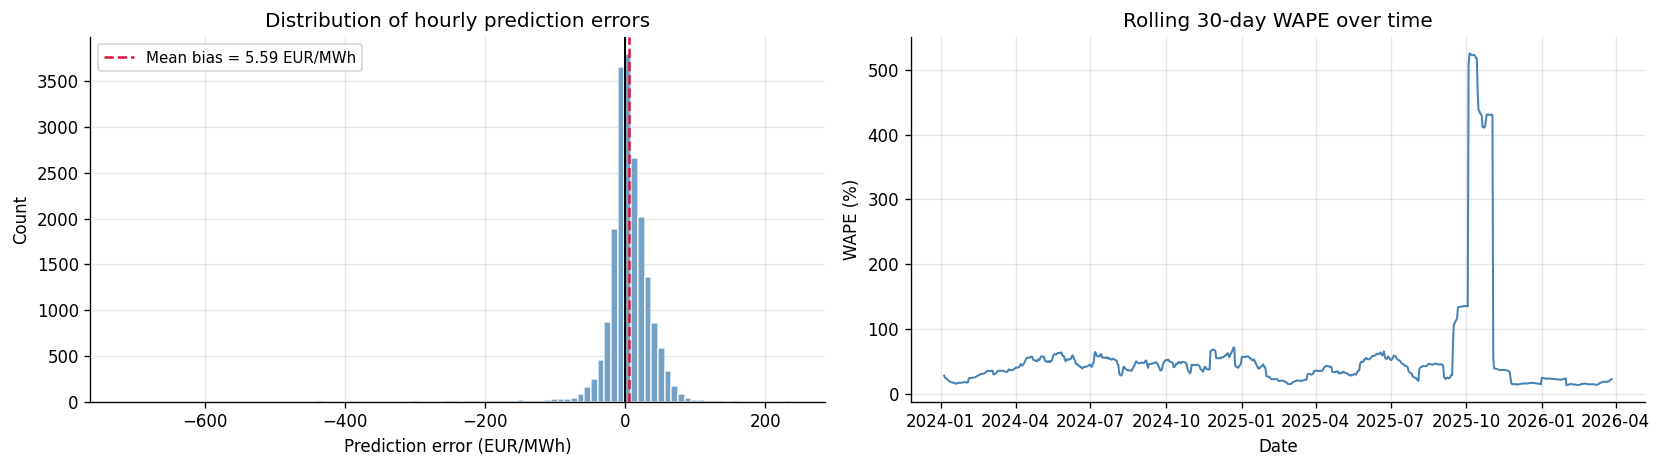

Saved: results/error_distribution.png
Mean error (bias):      5.59 EUR/MWh
Error std:              31.16 EUR/MWh
Median absolute error:  13.81 EUR/MWh
90th pct absolute error:45.36 EUR/MWh


In [30]:
# Flatten all hourly prediction errors.
errors_raw = df_predictions[pred_cols].values - df_predictions[hour_cols].values
errors = errors_raw.ravel()
errors = errors[~np.isnan(errors)]

# Compute WAPE per day, then smooth with a 30-day rolling window.
daily_wape_vals = []
for _, row in df_predictions.iterrows():
    a = row[hour_cols].values.astype(float)
    p = row[pred_cols].values.astype(float)
    daily_wape_vals.append(wape(a, p))

daily_wape_series = pd.Series(
    daily_wape_vals,
    index=pd.to_datetime(df_predictions["date"])
)
rolling_wape = daily_wape_series.rolling(30, min_periods=5).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(errors, bins=100, color="steelblue", alpha=0.75, edgecolor="white")
ax1.axvline(0, color="black", linewidth=1.2)
ax1.axvline(errors.mean(), color="crimson", linewidth=1.5, linestyle="--",
            label=f"Mean bias = {errors.mean():.2f} EUR/MWh")
ax1.set_xlabel("Prediction error (EUR/MWh)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of hourly prediction errors")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(daily_wape_series.index, rolling_wape,
         color="steelblue", linewidth=1.2)
ax2.set_xlabel("Date")
ax2.set_ylabel("WAPE (%)")
ax2.set_title("Rolling 30-day WAPE over time")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/error_distribution.png", dpi=120)
plt.show()
print("Saved: results/error_distribution.png")

print(f"Mean error (bias):      {errors.mean():.2f} EUR/MWh")
print(f"Error std:              {errors.std():.2f} EUR/MWh")
print(f"Median absolute error:  {np.median(np.abs(errors)):.2f} EUR/MWh")
print(f"90th pct absolute error:{np.percentile(np.abs(errors), 90):.2f} EUR/MWh")


### Classifier Regime Probabilities Over Time

The stacked area chart shows how the classifier allocates probability mass across the four regimes day by day. Persistent blue (Leaf A) bands indicate periods of sustained negative prices, red (Leaf B) bands indicate spike clustering. Wide green or orange areas reflect the dominant normal-day regimes. Sudden shifts in the colour mix can reveal structural changes in DK1 market conditions that fall outside the training distribution.

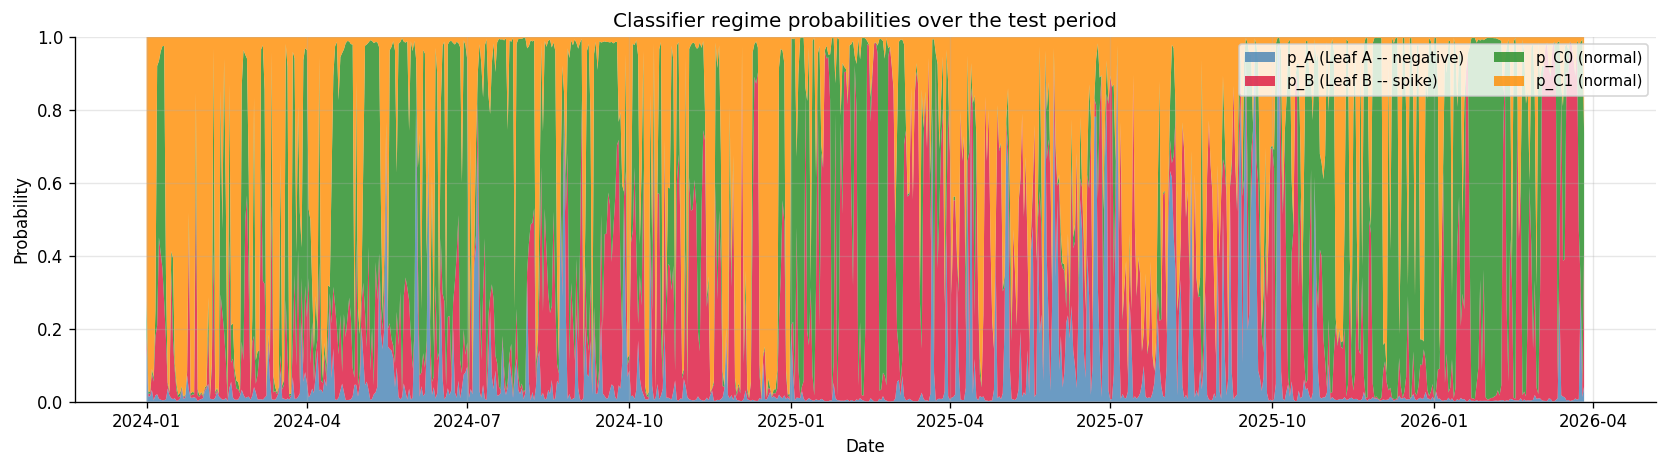

Saved: results/regime_probabilities.png


In [31]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.stackplot(
    pd.to_datetime(df_predictions["date"]),
    df_predictions["p_A"],
    df_predictions["p_B"],
    df_predictions["p_C0"],
    df_predictions["p_C1"],
    labels=["p_A (Leaf A -- negative)", "p_B (Leaf B -- spike)",
            "p_C0 (normal)", "p_C1 (normal)"],
    colors=["steelblue", "crimson", "forestgreen", "darkorange"],
    alpha=0.8
)
ax.set_xlabel("Date")
ax.set_ylabel("Probability")
ax.set_title("Classifier regime probabilities over the test period")
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/regime_probabilities.png", dpi=120)
plt.show()
print("Saved: results/regime_probabilities.png")


### Best and Worst Predicted Days

Inspecting the individual days with the highest and lowest daily WAPE shows whether failures concentrate in specific market conditions or are scattered randomly. Clustered failures suggest a systematic gap in the feature set.

In [32]:
df_predictions["daily_wape"] = daily_wape_vals

# MAPE: mean over hours of |actual - predicted| / |actual|, skipping hours where actual == 0.
daily_mape_vals = []
for _, row in df_predictions.iterrows():
    a = row[hour_cols].values.astype(float)
    p = row[pred_cols].values.astype(float)
    mask = ~(np.isnan(a) | np.isnan(p)) & (np.abs(a) > 0)
    if mask.sum() > 0:
        daily_mape_vals.append(100 * np.mean(np.abs(a[mask] - p[mask]) / np.abs(a[mask])))
    else:
        daily_mape_vals.append(np.nan)
df_predictions["daily_mape"] = daily_mape_vals

cols_show = ["date", "dominant_regime", "daily_mape", "daily_wape", "actual_mean", "pred_mean"]
worst = df_predictions.nlargest(10, "daily_wape")[cols_show].copy()
best  = df_predictions.nsmallest(10, "daily_wape")[cols_show].copy()

worst["regime_name"] = worst["dominant_regime"].map(regime_names)
best["regime_name"]  = best["dominant_regime"].map(regime_names)

display_cols = ["date", "regime_name", "daily_mape", "daily_wape", "actual_mean", "pred_mean"]
rename_map   = {"daily_mape": "MAPE%", "daily_wape": "WAPE%",
                "actual_mean": "actual_mean_eur", "pred_mean": "pred_mean_eur"}

print("=== 10 worst predicted days (by WAPE) ===")
print(worst[display_cols].rename(columns=rename_map).round(2).to_string(index=False))

print("=== 10 best predicted days (by WAPE) ===")
print(best[display_cols].rename(columns=rename_map).round(2).to_string(index=False))

print("=== Worst-day regime breakdown ===")
print(worst["regime_name"].value_counts().to_string())

=== 10 worst predicted days (by WAPE) ===
      date       regime_name    MAPE%    WAPE%  actual_mean_eur  pred_mean_eur
2025-10-04 Leaf A (negative) 28520.00 11226.48            -0.13          22.69
2025-09-15 Leaf A (negative) 46885.73  1496.88             2.30          28.24
2025-09-16 Leaf A (negative)  2850.89   912.46             4.16          40.56
2024-11-24       C1 (normal) 15090.26   844.20             4.19          40.45
2025-08-05 Leaf A (negative)  5351.06   553.98            -0.04          -4.90
2025-09-21 Leaf A (negative) 64230.88   534.76             8.70          26.92
2025-10-05 Leaf A (negative) 13063.97   521.38             3.41          24.56
2024-07-06 Leaf A (negative) 18926.23   411.92             9.31          11.51
2025-01-01       C0 (normal)   777.51   354.97             6.12          21.58
2024-11-01       C1 (normal)   698.58   351.35             9.87          43.39
=== 10 best predicted days (by WAPE) ===
      date    regime_name  MAPE%  WAPE%  actual_

In [33]:
# MAE per day: mean absolute error across all 24 hours.
daily_mae_vals = []
for _, row in df_predictions.iterrows():
    a = row[hour_cols].values.astype(float)
    p = row[pred_cols].values.astype(float)
    mask = ~(np.isnan(a) | np.isnan(p))
    daily_mae_vals.append(np.abs(a[mask] - p[mask]).mean() if mask.sum() > 0 else np.nan)
df_predictions["daily_mae"] = daily_mae_vals

cols_show = ["date", "dominant_regime", "daily_mae", "daily_mape", "daily_wape", "actual_mean", "pred_mean"]
worst_mae = df_predictions.nlargest(10, "daily_mae")[cols_show].copy()
best_mae  = df_predictions.nsmallest(10, "daily_mae")[cols_show].copy()

worst_mae["regime_name"] = worst_mae["dominant_regime"].map(regime_names)
best_mae["regime_name"]  = best_mae["dominant_regime"].map(regime_names)

display_cols = ["date", "regime_name", "daily_mae", "daily_mape", "daily_wape", "actual_mean", "pred_mean"]
rename_map   = {"daily_mae": "MAE", "daily_mape": "MAPE%", "daily_wape": "WAPE%",
                "actual_mean": "actual_mean_eur", "pred_mean": "pred_mean_eur"}

print("=== 10 worst predicted days (by MAE) ===")
print(worst_mae[display_cols].rename(columns=rename_map).round(2).to_string(index=False))

print("=== 10 best predicted days (by MAE) ===")
print(best_mae[display_cols].rename(columns=rename_map).round(2).to_string(index=False))

print("=== Worst-day regime breakdown ===")
print(worst_mae["regime_name"].value_counts().to_string())

=== 10 worst predicted days (by MAE) ===
      date       regime_name    MAE    MAPE%    WAPE%  actual_mean_eur  pred_mean_eur
2024-12-12    Leaf B (spike) 238.04    42.55    60.16           395.66         160.55
2024-12-11    Leaf B (spike) 108.62    33.24    42.46           255.80         148.43
2025-01-15       C1 (normal) 104.50    43.00    51.67           202.27          97.76
2025-10-04 Leaf A (negative)  98.55 28520.00 11226.48            -0.13          22.69
2025-11-25    Leaf B (spike)  86.08    30.80    41.44           207.70         122.85
2025-01-20    Leaf B (spike)  65.84    19.75    28.42           231.61         165.78
2025-01-16    Leaf B (spike)  58.88    70.50    62.02            94.93         153.81
2025-05-26 Leaf A (negative)  56.77 11633.24   120.87            46.65          79.36
2025-05-30 Leaf A (negative)  55.15 20114.48   118.96            46.09          -6.06
2025-09-13 Leaf A (negative)  51.58  1115.57   112.66            45.78          94.80
=== 10 best p

### Random Day Diagnostics

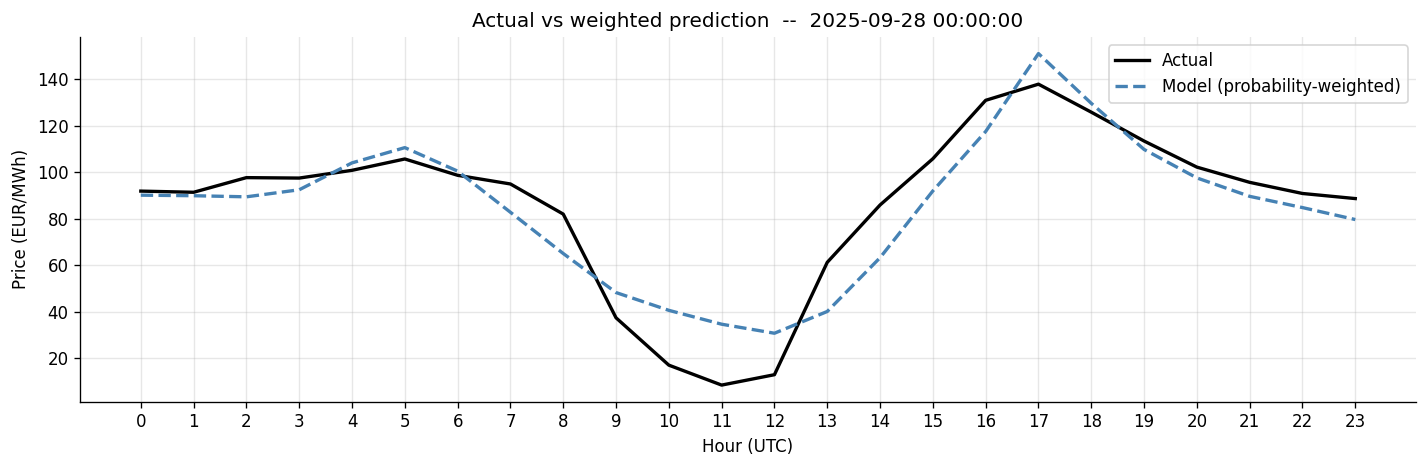

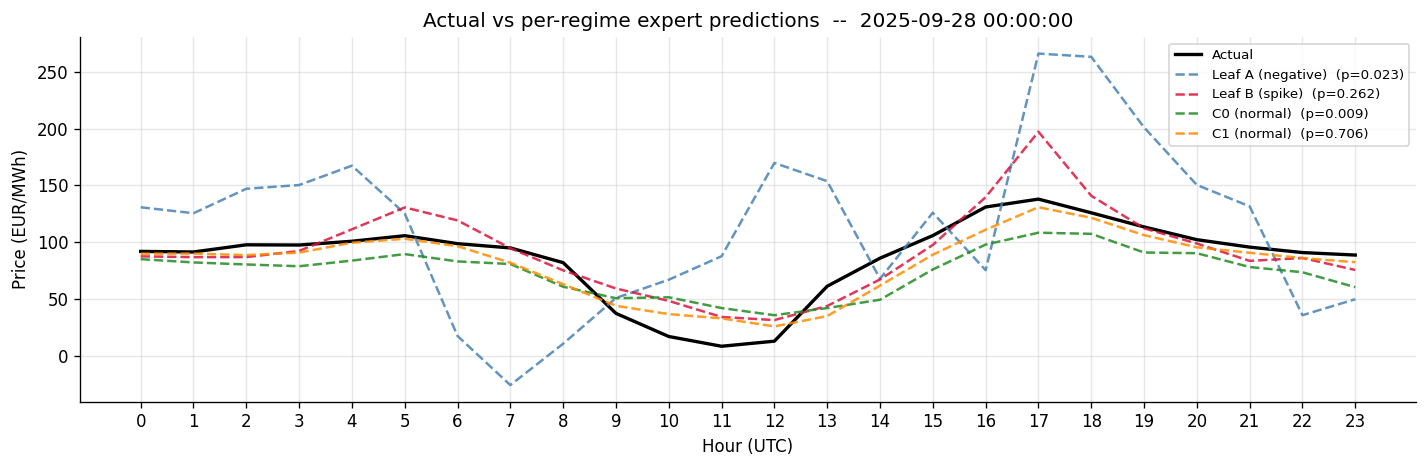

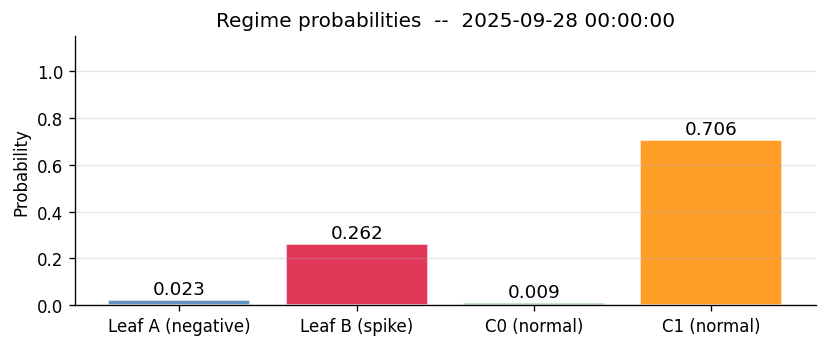


=== All features for 2025-09-28 00:00:00 ===
  price_mean_lag1              81.8517
  price_std_lag1               38.8451
  price_min_lag1               5.9900
  price_max_lag1               145.9200
  price_neg_frac_lag1          0.0000
  was_negative_lag1            0.0000
  price_range_lag1             139.9300
  pivot_hour_peak_lag1         17.0000
  pivot_hour_trough_lag1       10.0000
  pivot_peak_sin               -0.9659
  pivot_peak_cos               -0.2588
  pivot_trough_sin             0.5000
  pivot_trough_cos             -0.8660
  price_roll3_mean             76.3931
  price_roll7_mean             66.7864
  neg_streak_length            0.0000
  spike_streak_length          0.0000
  ttf_lag1                     32.4560
  ttf_return_1d                0.0173
  ttf_return_3d                0.0192
  ttf_roll7_std                0.2308
  co2_lag1                     72.7750
  co2_return_1d                -0.0034
  brent_return_3d              0.0428
  spark_spread_proxy      

In [42]:
# ---- Set date here ----
date = df_predictions["date"].sample().iloc[0]
# ------------------------


_date = pd.Timestamp(date)

# Locate prediction row for this date.
_pred_row = df_predictions[pd.to_datetime(df_predictions["date"]) == _date]
if len(_pred_row) == 0:
    print(f"Date {date} not found in predictions.")
    print(f"Available range: {df_predictions['date'].min()} -> {df_predictions['date'].max()}")
else:
    _pred_row = _pred_row.iloc[0]

    # Identify which fold this date belongs to.
    _fold_idx = next(
        (i for i, (_, _, te_s, te_e) in enumerate(config["fold_definitions"])
         if pd.Timestamp(te_s) <= _date <= pd.Timestamp(te_e)),
        None
    )
    if _fold_idx is None:
        print(f"Date {date} is not in any fold test window.")
    else:
        _models   = all_models[_fold_idx]
        _clf_cols = _models["clf_feature_cols"]

        # Rebuild features with the fold-specific spike threshold so
        # spike_streak_length matches what the model was trained on.
        with contextlib.redirect_stdout(io.StringIO()):
            _df_spike = build_daily_features(df_hourly, spike_threshold=_models["spike_threshold"])

         
        # Join pivot hours into _df_spike so _clf_cols (which now includes h00-h23)
        # can be satisfied. price_pivot_lag1 is already in scope from Section 2.
        _df_spike_clf = pd.concat([_df_spike, price_pivot_lag1], axis=1)
        _feat_row = _df_spike_clf.loc[[_date], _clf_cols].values  # (1, n_features)

        _hours  = list(range(24))
        _actual = np.array([_pred_row[f"h{h:02d}"]      for h in _hours])
        _pred_w = np.array([_pred_row[f"pred_h{h:02d}"] for h in _hours])
        _probs  = np.array([_pred_row["p_A"], _pred_row["p_B"],
                            _pred_row["p_C0"], _pred_row["p_C1"]])

        _r_colors = ["steelblue", "crimson", "forestgreen", "darkorange"]
        _r_labels = ["Leaf A (negative)", "Leaf B (spike)", "C0 (normal)", "C1 (normal)"]

        # Per-regime expert model predictions (unweighted curves).
        _regime_preds = np.array([
            [_models["expert_models"][r][h].predict(_feat_row)[0] for h in _hours]
            for r in range(4)
        ])

        # ---- Plot 1: actual vs weighted model prediction ----
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(_hours, _actual, color="black",     linewidth=2,   label="Actual")
        ax.plot(_hours, _pred_w, color="steelblue", linewidth=2,
                linestyle="--", label="Model (probability-weighted)")
        ax.set_title(f"Actual vs weighted prediction  --  {date}")
        ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Price (EUR/MWh)")
        ax.set_xticks(_hours); ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        # ---- Plot 2: actual + all four regime expert curves ----
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(_hours, _actual, color="black", linewidth=2, label="Actual")
        for r in range(4):
            ax.plot(_hours, _regime_preds[r], color=_r_colors[r], linewidth=1.5,
                    linestyle="--", alpha=0.85,
                    label=f"{_r_labels[r]}  (p={_probs[r]:.3f})")
        ax.set_title(f"Actual vs per-regime expert predictions  --  {date}")
        ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Price (EUR/MWh)")
        ax.set_xticks(_hours); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        # ---- Plot 3: regime probabilities ----
        fig, ax = plt.subplots(figsize=(7, 3))
        bars = ax.bar(_r_labels, _probs, color=_r_colors, edgecolor="white", alpha=0.85)
        for bar, p in zip(bars, _probs):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{p:.3f}", ha="center", va="bottom", fontsize=11)
        ax.set_ylim(0, 1.15); ax.set_ylabel("Probability")
        ax.set_title(f"Regime probabilities  --  {date}")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout(); plt.show()

        # ---- Feature table ----
        print(f"\n=== All features for {date} ===")
        for col, val in _df_spike_clf.loc[_date, _clf_cols].items():
            print(f"  {col:<28s} {val:.4f}")
